#1.0 Data Loading

#### The following steps include importing the libraries and loading the data in

In [ ]:
#importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

#Importing csv file as dataframe
ipl_data=pd.read_csv('year_enhanced_ipl_data.csv')

ipl_data

,Year,Team,Player,Role,BasePrice,WinningBid,CappedStatus,Overseas,RTM,Source,...,stats_BBI,stats_Bowl Av,stats_5,stats_Ct,stats_St,stats_Ave Diff,stats_Role,match_type,matched_stats_player,matched_stats_year
0,2014,Sunrisers Hyderabad,Aaron Finch,Batsman,NaN,40000000.0,NaN,True,NaN,historical,...,-,-,-,6,0,-,NaN,variation_year,AJ Finch,2014
1,2015,Mumbai Indians,Aaron Finch,Batsman,NaN,32000000.0,NaN,True,NaN,historical,...,-,-,-,0,0,-,NaN,variation_year,AJ Finch,2015
2,2016,Gujarat Lions,Aaron Finch,Batsman,NaN,10000000.0,NaN,True,NaN,historical,...,-,-,-,3,0,-,NaN,variation_year,AJ Finch,2016
3,2018,Punjab Kings,Aaron Finch,Batsman,NaN,62000000.0,NaN,True,NaN,historical,...,-,-,-,4,0,-,NaN,variation_year,AJ Finch,2018
4,2020,Royal Challengers Bangalore,Aaron Finch,Batsman,NaN,44000000.0,NaN,True,NaN,historical,...,-,-,-,3,0,-,NaN,variation_year,AJ Finch,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1934,2025,Sunrisers Hyderabad,Jitesh Sharma,Wicket Keeper,10000000.0,110000000.0,NaN,False,False,2025_auction,...,-,-,-,14,1,-,NaN,variation_year,JM Sharma,2025
1935,2025,Sunrisers Hyderabad,T Natarajan,Bowler,20000000.0,107500000.0,NaN,False,False,2025_auction,...,-,-,-,-,-,-,NaN,exact_year,T Natarajan,2025
1936,2025,Sunrisers Hyderabad,Kagiso Rabada,Bowler,20000000.0,107500000.0,NaN,False,False,2025_auction,...,1/41,41.50,0,0,0,-,NaN,variation_year,K Rabada,2025
1937,2025,Sunrisers Hyderabad,Bhuvneshwar Kumar,Bowler,20000000.0,107500000.0,NaN,False,False,2025_auction,...,3/33,28.25,0,2,0,-18.24,NaN,variation_year,B Kumar,2025


In [ ]:
#Basic Information to verify whether the data was collected properly and verified

#Dimensions of Dataframe
print("The shape of the dataset is:", ipl_data.shape)

The shape of the dataset is: (1939, 28)


In [ ]:
#To check column names
ipl_data.columns



Index(['Year', 'Team', 'Player', 'Role', 'BasePrice', 'WinningBid',
       'CappedStatus', 'Overseas', 'RTM', 'Source', 'DuplicateFlag',
       'clean_team', 'stats_Mat', 'stats_Runs', 'stats_HS', 'stats_Bat Av',
       'stats_100', 'stats_Wkts', 'stats_BBI', 'stats_Bowl Av', 'stats_5',
       'stats_Ct', 'stats_St', 'stats_Ave Diff', 'stats_Role', 'match_type',
       'matched_stats_player', 'matched_stats_year'],
      dtype='object')

In [ ]:
#To check count of Null and Non-Null values
ipl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1939 entries, 0 to 1938
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  1939 non-null   int64  
 1   Team                  1939 non-null   object 
 2   Player                1939 non-null   object 
 3   Role                  1289 non-null   object 
 4   BasePrice             969 non-null    float64
 5   WinningBid            1939 non-null   float64
 6   CappedStatus          182 non-null    object 
 7   Overseas              1939 non-null   bool   
 8   RTM                   969 non-null    object 
 9   Source                1939 non-null   object 
 10  DuplicateFlag         1939 non-null   bool   
 11  clean_team            1939 non-null   object 
 12  stats_Mat             1939 non-null   int64  
 13  stats_Runs            1939 non-null   object 
 14  stats_HS              1939 non-null   object 
 15  stats_Bat Av         

In [ ]:
ipl_data.head(5)

,Year,Team,Player,Role,BasePrice,WinningBid,CappedStatus,Overseas,RTM,Source,...,stats_BBI,stats_Bowl Av,stats_5,stats_Ct,stats_St,stats_Ave Diff,stats_Role,match_type,matched_stats_player,matched_stats_year
0,2014,Sunrisers Hyderabad,Aaron Finch,Batsman,NaN,40000000.0,NaN,True,NaN,historical,...,-,-,-,6,0,-,NaN,variation_year,AJ Finch,2014
1,2015,Mumbai Indians,Aaron Finch,Batsman,NaN,32000000.0,NaN,True,NaN,historical,...,-,-,-,0,0,-,NaN,variation_year,AJ Finch,2015
2,2016,Gujarat Lions,Aaron Finch,Batsman,NaN,10000000.0,NaN,True,NaN,historical,...,-,-,-,3,0,-,NaN,variation_year,AJ Finch,2016
3,2018,Punjab Kings,Aaron Finch,Batsman,NaN,62000000.0,NaN,True,NaN,historical,...,-,-,-,4,0,-,NaN,variation_year,AJ Finch,2018
4,2020,Royal Challengers Bangalore,Aaron Finch,Batsman,NaN,44000000.0,NaN,True,NaN,historical,...,-,-,-,3,0,-,NaN,variation_year,AJ Finch,2020


In [ ]:
ipl_data.drop(columns=['clean_team'],inplace=True)
#The 'clean_team' column was created to validate correct data alignment during dataset merging.
#It is no longer needed for analysis and can be safely removed.

In [ ]:
ipl_data.drop(columns=['CappedStatus'],inplace=True)
# Only 18.7% data were Non-Null values
#Dropping the column was the best option to be proceed with.

In [ ]:
ipl_data
fallback_count = ipl_data[ipl_data['match_type'] == 'fallback_year'].shape[0]
print("Number of rows with match_type = 'fallback_year':", fallback_count)


Number of rows with match_type = 'fallback_year': 463


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Replace '-' with NaN
ipl_data.replace('-', pd.NA, inplace=True)

# Convert relevant columns to numeric
numeric_columns = ['WinningBid', 'stats_Bat Av', 'stats_Bowl Av']
for col in numeric_columns:
    ipl_data[col] = pd.to_numeric(ipl_data[col], errors='coerce')



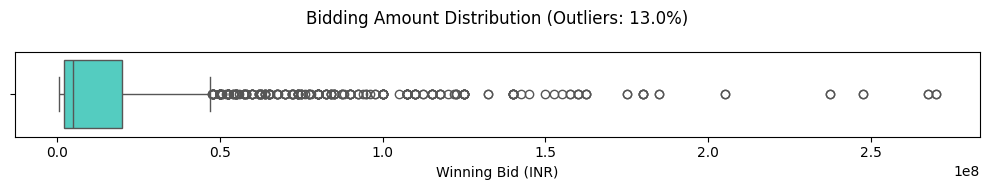

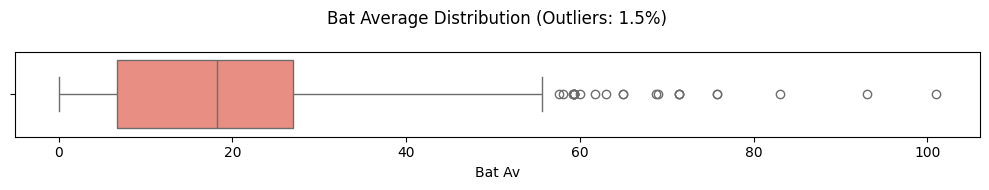

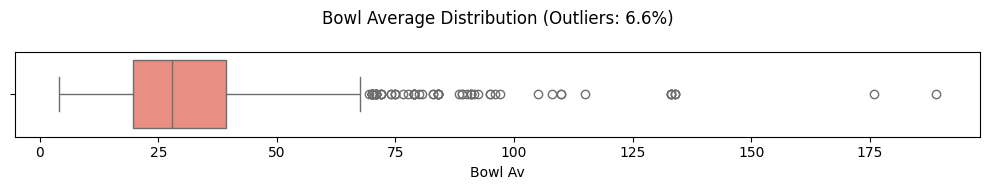

In [ ]:
# Function to calculate outlier percentage
def calculate_outlier_percentage(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return (len(outliers) / len(series.dropna())) * 100

# Separate Winning Bid outlier detection with enhanced visualization
plt.figure(figsize=(10, 2))
sns.boxplot(x=ipl_data['WinningBid'], color='turquoise')
outlier_pct = calculate_outlier_percentage(ipl_data['WinningBid'])
plt.title(f'Bidding Amount Distribution (Outliers: {outlier_pct:.1f}%)', fontsize=12, pad=20)
plt.xlabel('Winning Bid (INR)', fontsize=10)
plt.tight_layout()
plt.show()

# Performance metrics outlier detection
performance_metrics = ['stats_Bat Av', 'stats_Bowl Av']
for metric in performance_metrics:
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=ipl_data[metric], color='salmon')
    outlier_pct = calculate_outlier_percentage(ipl_data[metric])
    plt.title(f'{metric.replace("stats_", "").replace("Av", "Average")} Distribution (Outliers: {outlier_pct:.1f}%)',
              fontsize=12, pad=20)
    plt.xlabel(metric.replace("stats_", ""), fontsize=10)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Assuming ipl_data is already defined (e.g., loaded from a CSV)

# Step 1: Check for NaN values
print("NaN values in each column:\n", ipl_data.isna().sum())

# Step 2: Replace NaN values with median (numeric columns only)
ipl_data.fillna(ipl_data.median(numeric_only=True), inplace=True)

# Step 3: Check for any remaining NaN values
print("NaN values after filling:\n", ipl_data.isna().sum())

# Step 4: Check for infinite values only in numeric columns
numeric_cols = ipl_data.select_dtypes(include=[np.number])
print("Infinite values in numeric columns:\n", np.isinf(numeric_cols).sum())


NaN values in each column:
 Year                       0
Team                       0
Player                     0
Role                     650
BasePrice                970
WinningBid                 0
Overseas                   0
RTM                      970
Source                     0
DuplicateFlag              0
stats_Mat                  0
stats_Runs               170
stats_HS                 170
stats_Bat Av             342
stats_100                170
stats_Wkts               674
stats_BBI                839
stats_Bowl Av            839
stats_5                  674
stats_Ct                   2
stats_St                   2
stats_Ave Diff          1110
stats_Role              1939
match_type                 0
matched_stats_player       0
matched_stats_year         0
dtype: int64
NaN values after filling:
 Year                       0
Team                       0
Player                     0
Role                     650
BasePrice                  0
WinningBid                 0
Over

In [ ]:
import numpy as np
import pandas as pd

def calculate_player_metrics(ipl_data):
    """
    Calculates player metrics with:
    - Original expert formulas preserved
    - Robust NA handling
    - Strict 0-100 value ranges
    - Full protection against edge cases
    """

    # 1. Verify all required columns exist
    required_cols = ['stats_Bat Av', 'stats_Bowl Av', 'stats_Ct',
                    'stats_St', 'stats_Mat', 'stats_Runs',
                    'stats_Wkts', 'stats_Ave Diff', 'Player', 'Year']
    missing_cols = [col for col in required_cols if col not in ipl_data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # 2. Convert all stats to numeric and clean
    for col in required_cols:
        if col not in ['Player', 'Year']:
            ipl_data[col] = pd.to_numeric(ipl_data[col], errors='coerce').fillna(0)

    # 3. Batting Consistency (with single-year handling)
    def batting_consistency(x):
        if len(x) < 2:
            return x.iloc[0] if len(x) == 1 else 0  # Return actual value for single year
        std = x.std()
        if std < 1:  # Prevent division by tiny numbers
            std = 1
        return x.mean() / std

    ipl_data['Bat_Consistency'] = (
        ipl_data.groupby('Player')['stats_Bat Av']
        .transform(batting_consistency)
        .fillna(0)
    )

    # 4. Bowling Consistency (with single-year handling)
    def bowling_consistency(x):
        if len(x) < 2:
            return x.iloc[0] if len(x) == 1 else 0  # Return actual value for single year
        std = x.std()
        if std < 1:  # Prevent division by tiny numbers
            std = 1
        return x.mean() / std

    ipl_data['Bowl_Consistency'] = (
        ipl_data.groupby('Player')['stats_Bowl Av']
        .transform(bowling_consistency)
        .fillna(0)
    )

    # 5. Recent Form Calculation
    ipl_data = ipl_data.sort_values(['Player', 'Year'])

    def calculate_form(group):
        group = group.sort_values('Year', ascending=False)
        bat_avgs = group['stats_Bat Av'].values
        if len(bat_avgs) >= 3:
            return 0.5*bat_avgs[0] + 0.3*bat_avgs[1] + 0.2*bat_avgs[2]
        elif len(bat_avgs) >= 2:
            return 0.6*bat_avgs[0] + 0.4*bat_avgs[1]
        else:
            return bat_avgs[0] if len(bat_avgs) > 0 else 0

    ipl_data['Recent_Form'] = (
        ipl_data.groupby('Player', group_keys=False)
        .apply(lambda x: calculate_form(x))
        .fillna(0)
    )

    # 6. Dismissals per Match
    ipl_data['Dismissals_per_Match'] = (
        (ipl_data['stats_Ct'].fillna(0) + ipl_data['stats_St'].fillna(0)) /
        ipl_data['stats_Mat'].replace(0, 1)  # Avoid division by zero
    ).fillna(0)

    # 7. All-Rounder Score
    avg_runs = max(ipl_data['stats_Runs'].mean(), 1)
    avg_wkts = max(ipl_data['stats_Wkts'].mean(), 1)
    max_ave_diff = max(ipl_data['stats_Ave Diff'].abs().max(), 1)

    ipl_data['All_Rounder_Score'] = (
        (ipl_data['stats_Runs'].fillna(0) / avg_runs +
        ipl_data['stats_Wkts'].fillna(0) / avg_wkts +
        ipl_data['stats_Ave Diff'].abs().fillna(0) / max_ave_diff
    ).fillna(0) * 33.33)  # Scale to 0-100

    # 8. Final NA handling and value capping
    result_cols = ['Bat_Consistency', 'Bowl_Consistency',
                  'Recent_Form', 'Dismissals_per_Match',
                  'All_Rounder_Score']

    ipl_data[result_cols] = ipl_data[result_cols].fillna(0).clip(0, 100)

    # 9. Validation report
    na_count = ipl_data[result_cols].isna().sum().sum()
    if na_count > 0:
        print(f"Warning: Filled {na_count} NA values")
    else:
        print("All metrics calculated successfully with no NA values")

    range_report = "\n".join([
        f"- {col}: {ipl_data[col].min():.1f} to {ipl_data[col].max():.1f}"
        for col in result_cols
    ])
    print(f"Final value ranges:\n{range_report}")

    return ipl_data

# Usage example:
ipl_data = calculate_player_metrics(ipl_data)

All metrics calculated successfully with no NA values
Final value ranges:
- Bat_Consistency: 0.0 to 75.8
- Bowl_Consistency: 0.0 to 100.0
- Recent_Form: 0.0 to 0.0
- Dismissals_per_Match: 0.0 to 2.0
- All_Rounder_Score: 0.0 to 100.0


/tmp/ipykernel_23515/755605936.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: calculate_form(x))


In [ ]:

ipl_data.to_csv("ipl_data.csv", index=False)
ipl_data

,Year,Team,Player,Role,BasePrice,WinningBid,Overseas,RTM,Source,DuplicateFlag,...,stats_Ave Diff,stats_Role,match_type,matched_stats_player,matched_stats_year,Bat_Consistency,Bowl_Consistency,Dismissals_per_Match,All_Rounder_Score,Recent_Form
0,2014,Sunrisers Hyderabad,Aaron Finch,Batsman,NaN,40000000.0,True,NaN,historical,False,...,0.00,NaN,variation_year,AJ Finch,2014,2.196347,0.000000,0.461538,86.618417,0.0
1,2015,Mumbai Indians,Aaron Finch,Batsman,NaN,32000000.0,True,NaN,historical,False,...,0.00,NaN,variation_year,AJ Finch,2015,2.196347,0.000000,0.000000,6.447326,0.0
2,2016,Gujarat Lions,Aaron Finch,Batsman,NaN,10000000.0,True,NaN,historical,False,...,0.00,NaN,variation_year,AJ Finch,2016,2.196347,0.000000,0.230769,100.000000,0.0
3,2018,Punjab Kings,Aaron Finch,Batsman,NaN,62000000.0,True,NaN,historical,False,...,0.00,NaN,variation_year,AJ Finch,2018,2.196347,0.000000,0.400000,37.562679,0.0
4,2020,Royal Challengers Bangalore,Aaron Finch,Batsman,NaN,44000000.0,True,NaN,historical,False,...,0.00,NaN,variation_year,AJ Finch,2020,2.196347,0.000000,0.250000,75.125359,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,2018,Royal Challengers Bangalore,Yuzvendra Singh Chahal,Bowler,NaN,60000000.0,False,NaN,historical,False,...,0.00,NaN,variation_year,YS Chahal,2018,0.000000,23.104992,0.142857,60.849152,0.0
967,2014,Mumbai Indians,Zaheer Khan,Bowler,NaN,26000000.0,False,NaN,historical,False,...,-21.19,NaN,variation_year,Z Khan,2014,0.707107,5.260384,0.000000,31.531192,0.0
968,2015,Delhi Capitals,Zaheer Khan,Bowler,NaN,40000000.0,False,NaN,historical,False,...,0.00,NaN,variation_year,Z Khan,2015,0.707107,5.260384,0.000000,35.495339,0.0
969,2018,Rajasthan Royals,Zahir Khan Pakteen,Bowler,NaN,6000000.0,False,NaN,historical,False,...,0.00,NaN,fuzzy_team_year,SN Khan,2018,10.200000,0.000000,0.285714,14.296244,0.0


In [ ]:
# Drop columns that are constant or have only NaNs
features = ipl_data.loc[:, ipl_data.apply(pd.Series.nunique) > 1]

# Replace inf/-inf with NaN (if any)
features.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with any NaN values
features.dropna(inplace=True)


/tmp/ipykernel_23515/3193299167.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_23515/3193299167.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.dropna(inplace=True)


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assume ipl_data is your DataFrame

# Step 1: Drop irrelevant columns (target + identifiers)
features = ipl_data.drop(columns=['WinningBid', 'Player', 'Year'])

# Step 2: Keep only numeric features
features = features.select_dtypes(include=np.number)

# Step 3: Drop constant columns (those with only one unique value)
features = features.loc[:, features.apply(pd.Series.nunique) > 1]

# Step 4: Replace inf/-inf with NaN
features.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 5: Drop rows with any NaN values
original_shape = features.shape
features.dropna(inplace=True)
print(f"Dropped {original_shape[0] - features.shape[0]} rows due to NaNs or infs.")

# Step 6: Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns
vif_data["VIF"] = [
    variance_inflation_factor(features.values, i)
    for i in range(features.shape[1])
]

# Step 7: Round VIFs for readability
vif_data["VIF"] = vif_data["VIF"].round(2)

# Step 8: Sort and display VIFs below threshold
vif_sorted = vif_data.sort_values(by="VIF", ascending=False)
print("Features with VIF < 1000:")
print(vif_sorted[vif_sorted['VIF'] < 1000])

# Optional: Warn about high multicollinearity
high_vif = vif_sorted[vif_sorted['VIF'] > 10]
if not high_vif.empty:
    print("\n⚠️ Warning: High multicollinearity detected in these features:")
    print(high_vif)


Dropped 970 rows due to NaNs or infs.
Features with VIF < 1000:
                 Feature    VIF
13     All_Rounder_Score  47.96
1              stats_Mat  43.59
6               stats_Ct  19.89
4             stats_Wkts  13.77
9     matched_stats_year  13.28
2             stats_Runs  13.27
12  Dismissals_per_Match  10.58
3           stats_Bat Av   9.53
5          stats_Bowl Av   3.58
10       Bat_Consistency   2.32
8         stats_Ave Diff   2.27
11      Bowl_Consistency   1.84
0              BasePrice   1.22
7               stats_St   1.16

⚠️ Warning: High multicollinearity detected in these features:
                 Feature    VIF
13     All_Rounder_Score  47.96
1              stats_Mat  43.59
6               stats_Ct  19.89
4             stats_Wkts  13.77
9     matched_stats_year  13.28
2             stats_Runs  13.27
12  Dismissals_per_Match  10.58


Raw Correlation Values:
                      BasePrice  stats_Mat  stats_Runs  stats_Bat Av  \
BasePrice                  1.00       0.04        0.05          0.05   
stats_Mat                  0.04       1.00        0.32          0.19   
stats_Runs                 0.05       0.32        1.00          0.86   
stats_Bat Av               0.05       0.19        0.86          1.00   
stats_Wkts                -0.01       0.45       -0.44         -0.46   
stats_Bowl Av              0.01      -0.19       -0.35         -0.33   
stats_Ct                   0.07       0.67        0.46          0.38   
stats_St                   0.06       0.05        0.22          0.21   
stats_Ave Diff            -0.01      -0.03        0.29          0.28   
matched_stats_year         0.02      -0.21        0.03          0.10   
Bat_Consistency           -0.04       0.16        0.57          0.57   
Bowl_Consistency          -0.06      -0.03       -0.22         -0.20   
Dismissals_per_Match       0.07       0.

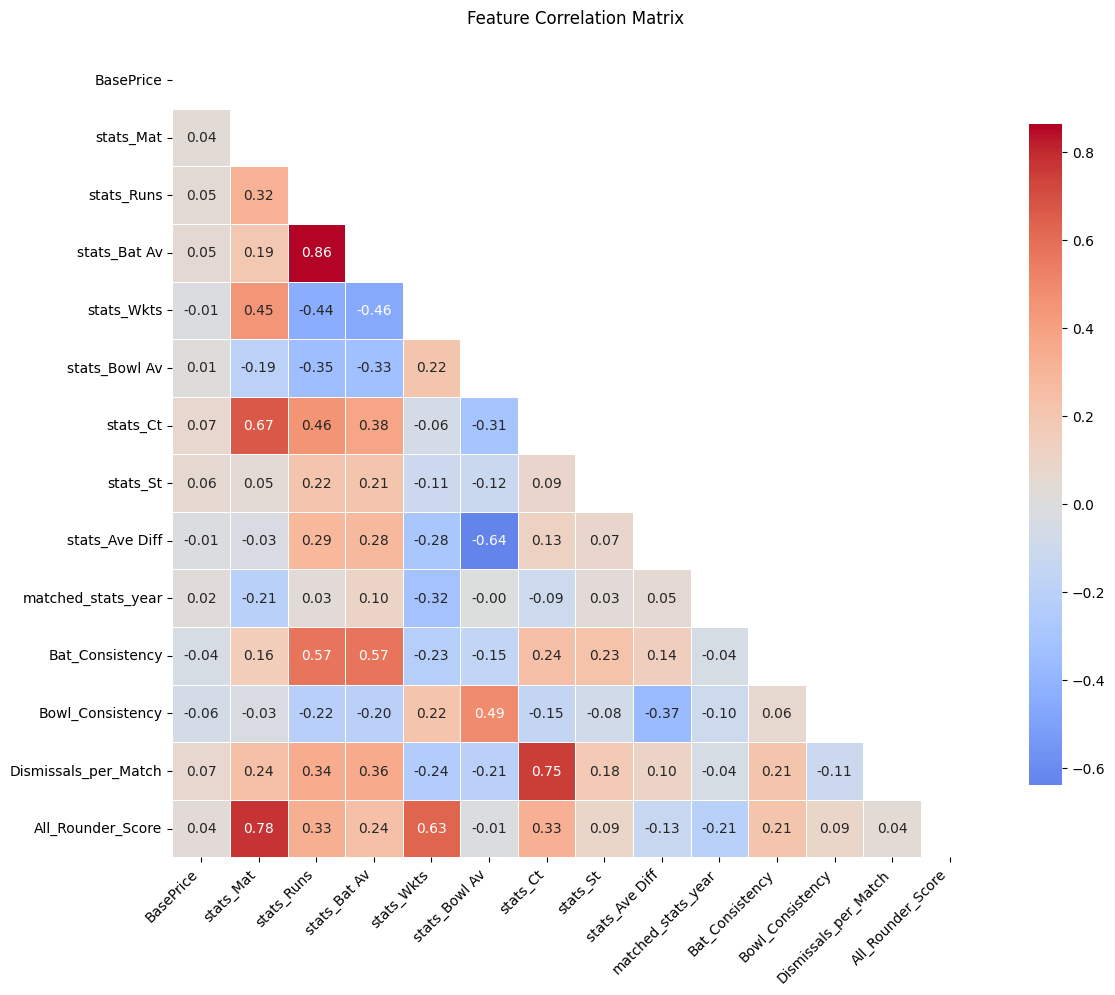


Correlation values saved to 'feature_correlations.csv'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr_matrix = features.corr()

# 1. Print the raw correlation values
print("Raw Correlation Values:")
print(corr_matrix.round(2))  # Rounded to 2 decimal places for readability

# 2. Create the visualization
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": 0.8})

plt.title("Feature Correlation Matrix", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Optional: Save correlation values to CSV
corr_matrix.to_csv('feature_correlations.csv')
print("\nCorrelation values saved to 'feature_correlations.csv'")

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    """Calculate Variance Inflation Factors for features"""
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i)
                      for i in range(df.shape[1])]
    return vif_data.round(2)

def optimize_features(ipl_data, vif_threshold=10):
    """
    Processes IPL data to reduce multicollinearity while preserving key metrics
    Returns:
    - final_data: DataFrame with optimized features and identifiers
    - vif_report: DataFrame with final VIF scores
    """
    # Create working copy of data
    features = ipl_data.copy()

    # Initial feature removal
    initial_drops = [
        'All_Rounder_Score', 'stats_Mat', 'stats_Ct',
        'stats_St', 'stats_Runs', 'matched_stats_year'
    ]
    features = features.drop(columns=initial_drops, errors='ignore')

    # Select key performance indicators
    performance_metrics = [
        'BasePrice', 'stats_Bat Av', 'stats_Wkts',
        'stats_Bowl Av', 'stats_Ave Diff', 'Bat_Consistency',
        'Bowl_Consistency', 'Dismissals_per_Match'
    ]
    features = features[performance_metrics]

    # Clean numeric data
    features = features.select_dtypes(include=np.number)
    features = features.loc[:, features.nunique() > 1]
    features.replace([np.inf, -np.inf], np.nan, inplace=True)
    original_rows = features.shape[0]
    features.dropna(inplace=True)
    print(f"Cleaning: Removed {original_rows - features.shape[0]} rows with invalid values")

    # Iterative VIF reduction
    high_vif = True
    while high_vif:
        vif_report = calculate_vif(features)
        current_max = vif_report['VIF'].max()

        if current_max <= vif_threshold:
            high_vif = False
        else:
            worst_feature = vif_report.loc[vif_report['VIF'].idxmax(), 'Feature']
            print(f"Removing '{worst_feature}' (VIF: {current_max})")
            features = features.drop(columns=[worst_feature])

    # Merge with identifiers and target
    final_data = pd.concat([
        ipl_data[['Player', 'Year', 'WinningBid']],
        features
    ], axis=1).dropna()

    # Final VIF report
    vif_report = calculate_vif(features).sort_values('VIF', ascending=False)
    print("\nOptimized feature set:")
    print(vif_report)
    print(f"\nFinal dataset shape: {final_data.shape}")

    return final_data, vif_report

# Correct usage example:
optimized_data, vif_report = optimize_features(ipl_data)
important_features = optimized_data.drop(
    columns=['Player', 'Year', 'WinningBid']
).columns.tolist()

print("\nImportant Features for Modeling:")
print(important_features)

Cleaning: Removed 970 rows with invalid values

Optimized feature set:
                Feature   VIF
1          stats_Bat Av  3.31
3         stats_Bowl Av  2.85
7  Dismissals_per_Match  2.58
4        stats_Ave Diff  2.16
5       Bat_Consistency  2.16
6      Bowl_Consistency  1.82
2            stats_Wkts  1.52
0             BasePrice  1.20

Final dataset shape: (969, 11)

Important Features for Modeling:
['BasePrice', 'stats_Bat Av', 'stats_Wkts', 'stats_Bowl Av', 'stats_Ave Diff', 'Bat_Consistency', 'Bowl_Consistency', 'Dismissals_per_Match']


Cleaning: Removed 970 rows with invalid values

Optimized feature set:
                Feature   VIF
1          stats_Bat Av  3.31
3         stats_Bowl Av  2.85
7  Dismissals_per_Match  2.58
4        stats_Ave Diff  2.16
5       Bat_Consistency  2.16
6      Bowl_Consistency  1.82
2            stats_Wkts  1.52
0             BasePrice  1.20

Final dataset shape: (969, 11)


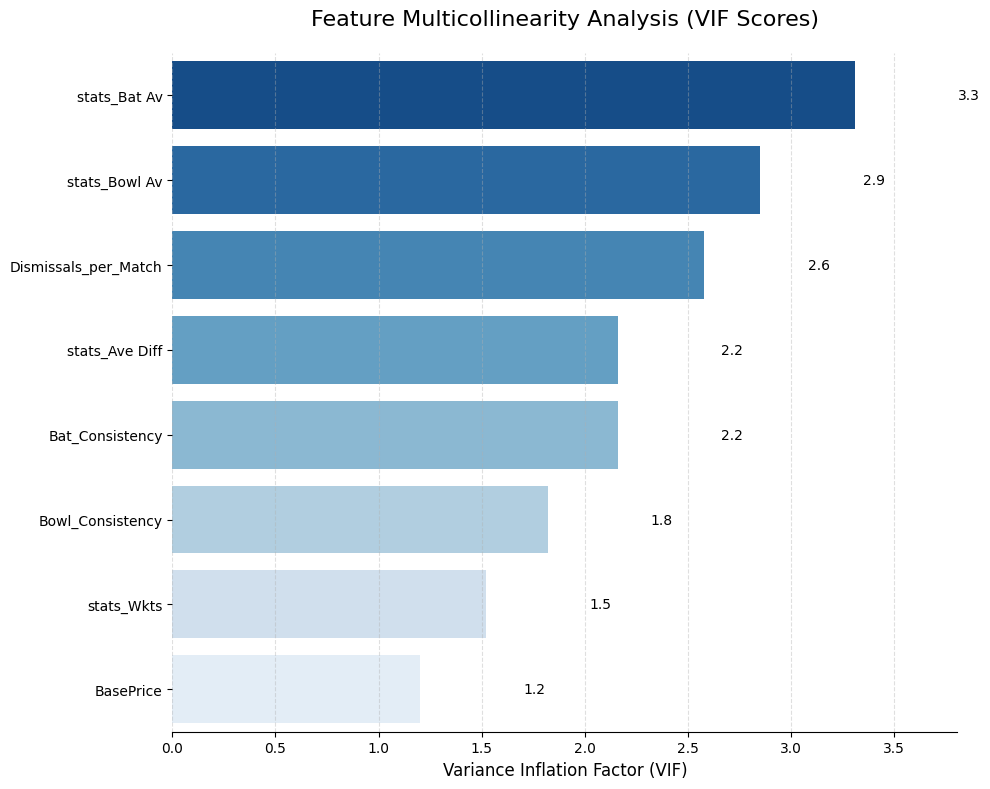

In [ ]:
# 1. Run optimization
optimized_data, vif_report = optimize_features(ipl_data)

# 2. Plot using the VIF report DataFrame
plt.figure(figsize=(10, 8))
sorted_vif = vif_report.sort_values(by='VIF', ascending=False)

ax = sns.barplot(
    y='Feature',
    x='VIF',
    data=sorted_vif,
    hue='Feature',  # Added to satisfy deprecation warning
    palette='Blues_r',
    saturation=0.8,
    dodge=False,
    legend=False  # Disable automatic legend
)

# Add value labels
for p in ax.patches:
    ax.text(p.get_width() + 0.5,
            p.get_y() + p.get_height()/2,
            f'{p.get_width():.1f}',
            va='center',
            ha='left',
            fontsize=10)

plt.title('Feature Multicollinearity Analysis (VIF Scores)',
         fontsize=16, pad=20)
plt.xlabel('Variance Inflation Factor (VIF)', fontsize=12)
plt.ylabel('')
plt.xlim(0, sorted_vif['VIF'].max() * 1.15)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Use only important features from the VIF result
important_features = [
    'stats_Bowl Av','stats_Bat Av', 'Dismissals_per_Match', 'stats_Ave Diff',
     'stats_Wkts', 'Bowl_Consistency',
    'stats_St', 'Bat_Consistency'
]

# Prepare X and y
X = ipl_data[important_features]
y = ipl_data['WinningBid']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for regression and ensemble methods)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve

def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    print(f"\n--- {model_name} ---")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5)
    )
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
    plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Cross-validation score")
    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training examples")
    plt.ylabel("R² Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



--- Linear Regression ---
R² Score: 0.0337
RMSE: 34977480.0453


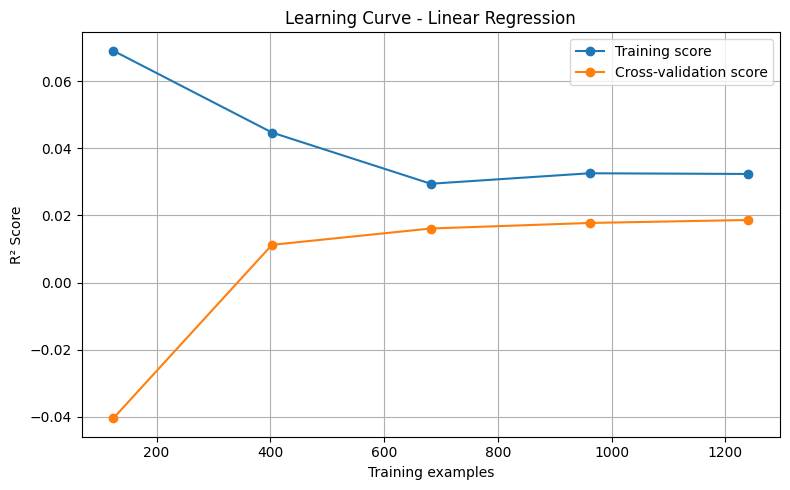

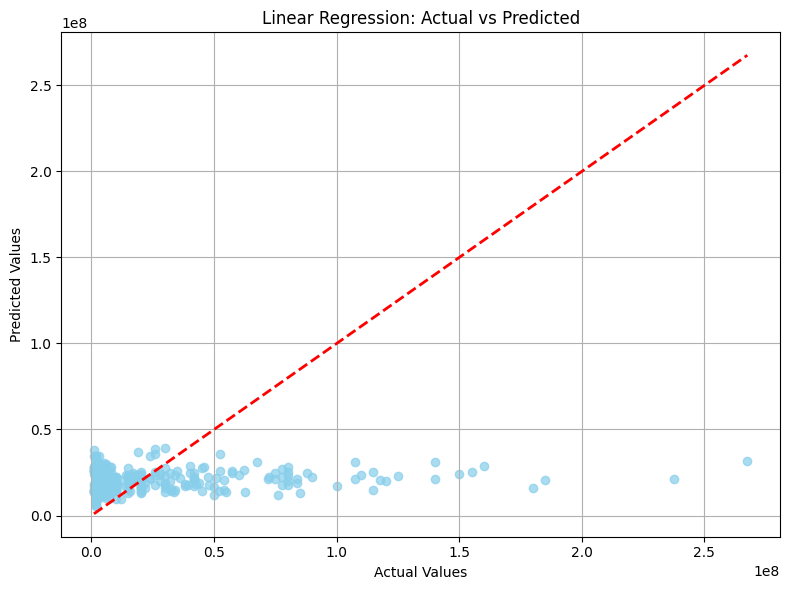

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Fit the model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
evaluate_model(lr, "Linear Regression", X_train_scaled, X_test_scaled, y_train, y_test)

# Visualization: Actual vs Predicted
y_pred = lr.predict(X_test_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='skyblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


--- Ridge Regression ---
R² Score: 0.0336
RMSE: 34977726.4000


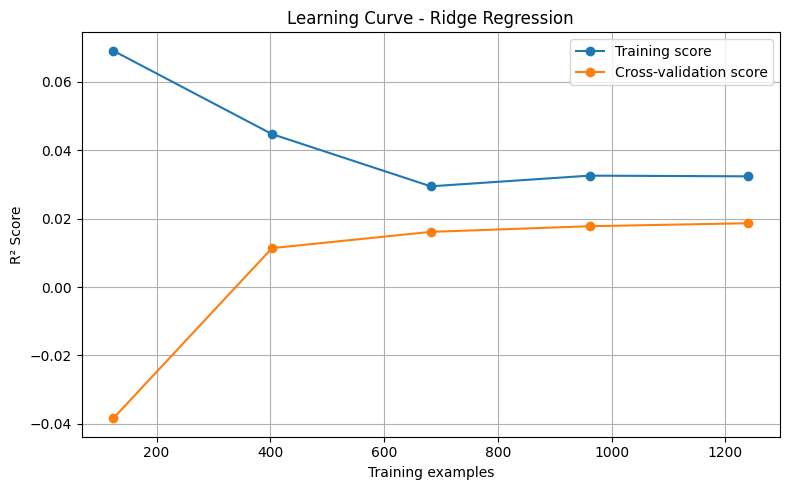

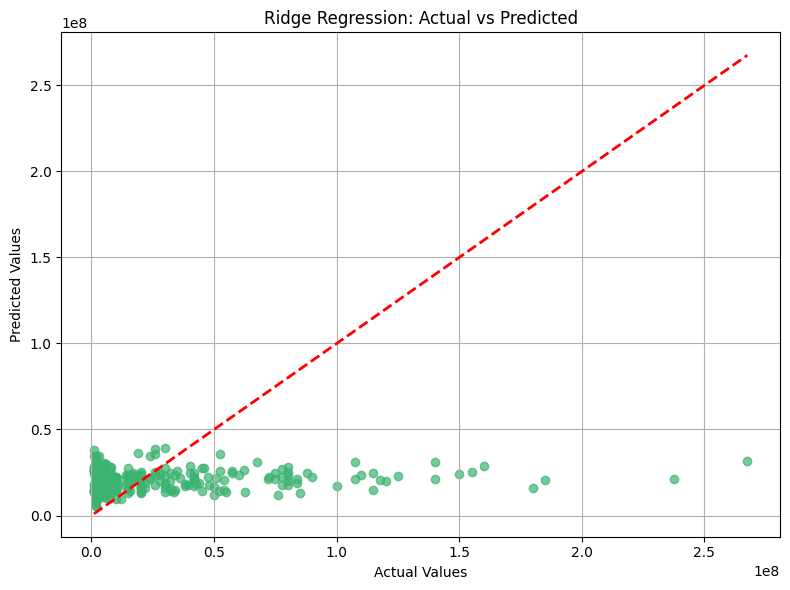

In [ ]:
from sklearn.linear_model import Ridge


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
evaluate_model(ridge, "Ridge Regression", X_train_scaled, X_test_scaled, y_train, y_test)

import matplotlib.pyplot as plt

# Predict on test data
y_pred_ridge = ridge.predict(X_test_scaled)

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.7, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Ridge Regression: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()




--- Lasso Regression ---
R² Score: 0.0337
RMSE: 34977480.0528


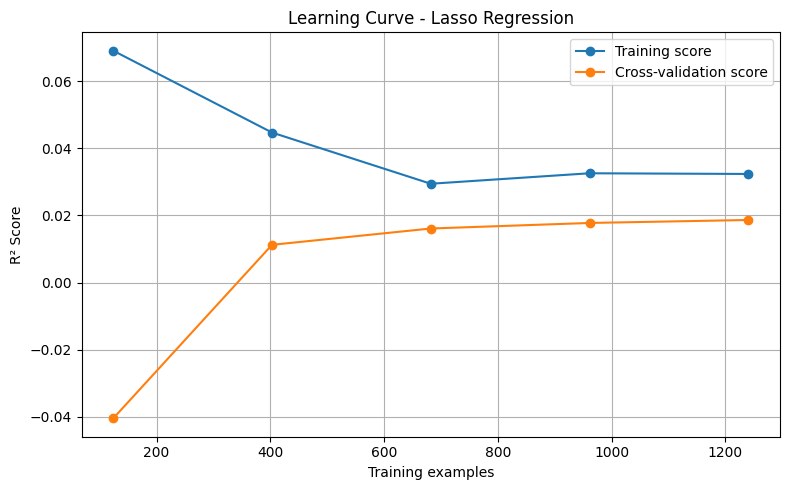

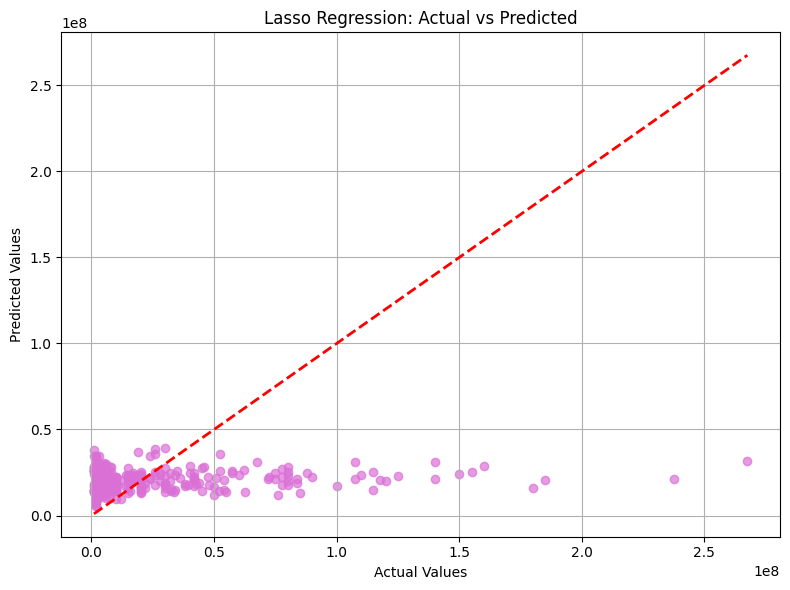

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
evaluate_model(lasso, "Lasso Regression", X_train_scaled, X_test_scaled, y_train, y_test)


# Predict on test data
y_pred_lasso = lasso.predict(X_test_scaled)

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.7, color='orchid')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Lasso Regression: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()



--- Random Forest ---
R² Score: 0.3939
RMSE: 27700260.8797


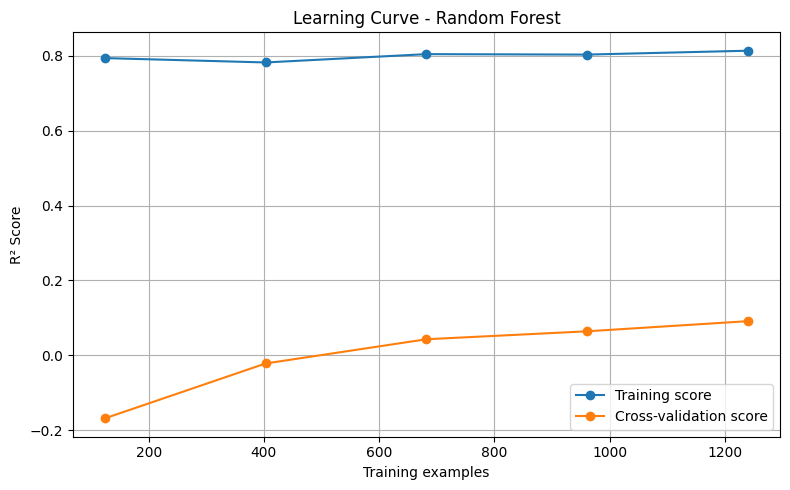

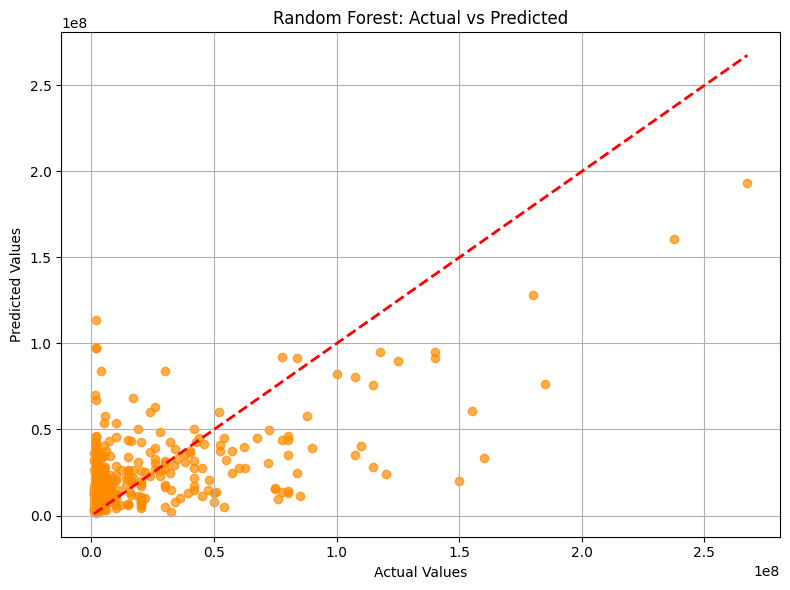

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
evaluate_model(rf, "Random Forest", X_train_scaled, X_test_scaled, y_train, y_test)


# Predict on test data
y_pred_rf = rf.predict(X_test_scaled)

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()



--- Gradient Boosting ---
R² Score: 0.2909
RMSE: 29963041.8241


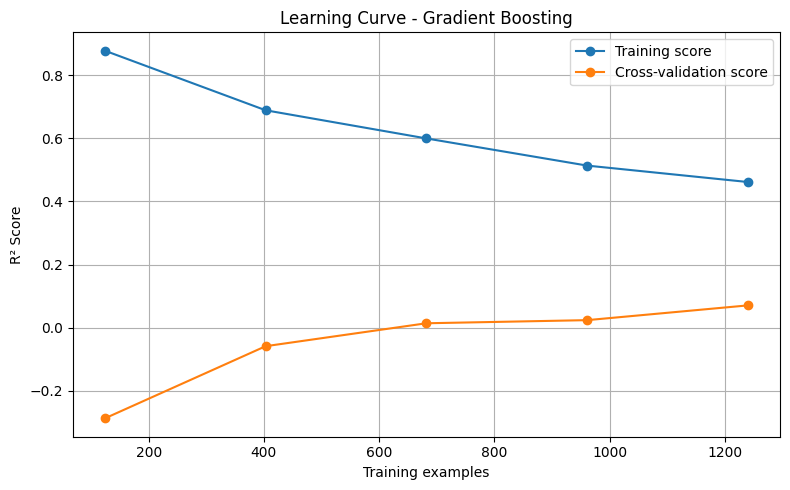

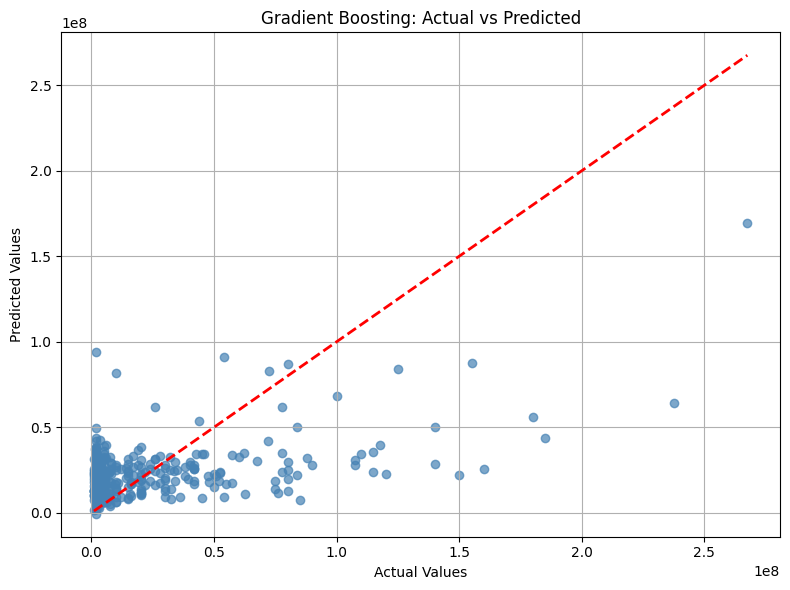

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
evaluate_model(gb, "Gradient Boosting", X_train_scaled, X_test_scaled, y_train, y_test)

# Predict on test data
y_pred_gb = gb.predict(X_test_scaled)

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Gradient Boosting: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()



--- XGBoost ---
R² Score: 0.3862
RMSE: 27875785.8227


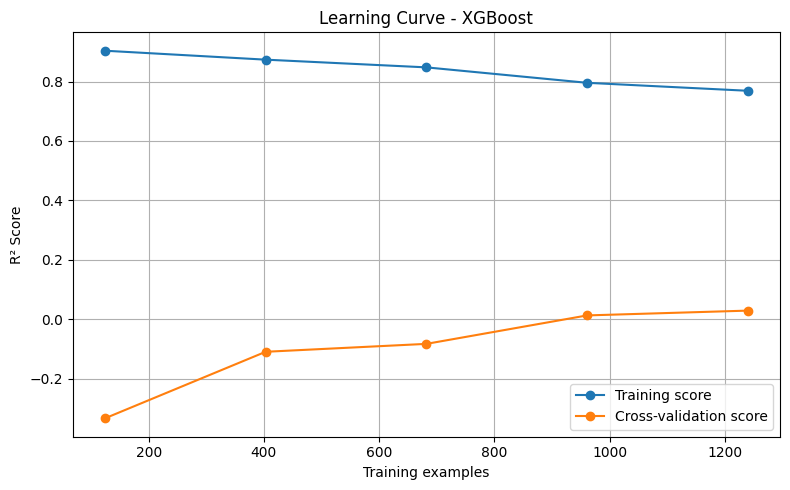

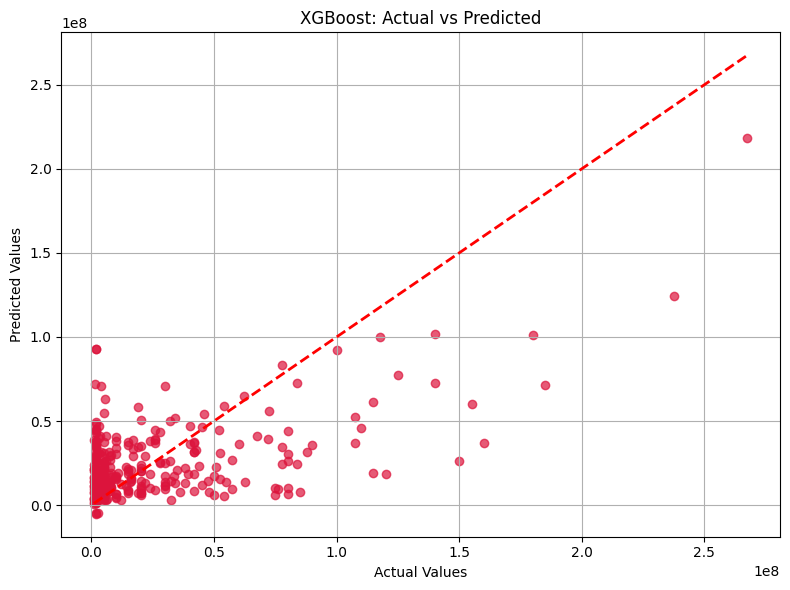

In [ ]:

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train_scaled, y_train)
evaluate_model(xgb, "XGBoost", X_train_scaled, X_test_scaled, y_train, y_test)

# Predict on test data
y_pred_xgb = xgb.predict(X_test_scaled)

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.7, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
!pip install xgboost

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Optimized R² Score: 0.3108
Optimized RMSE: 29539469.2629


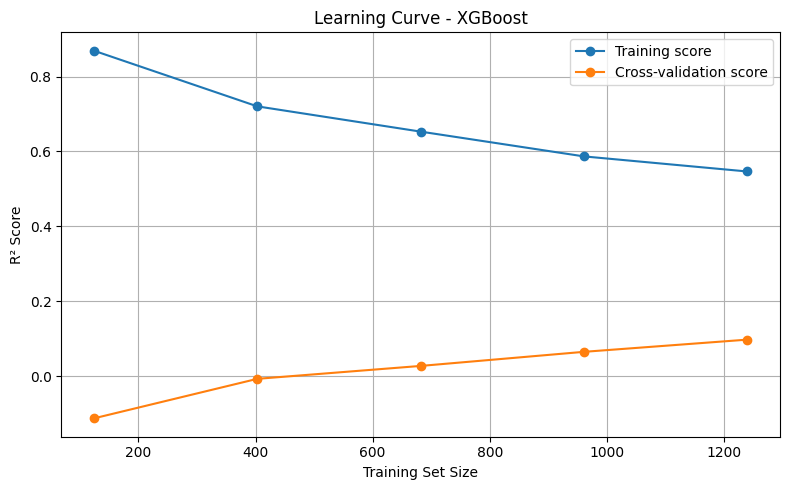

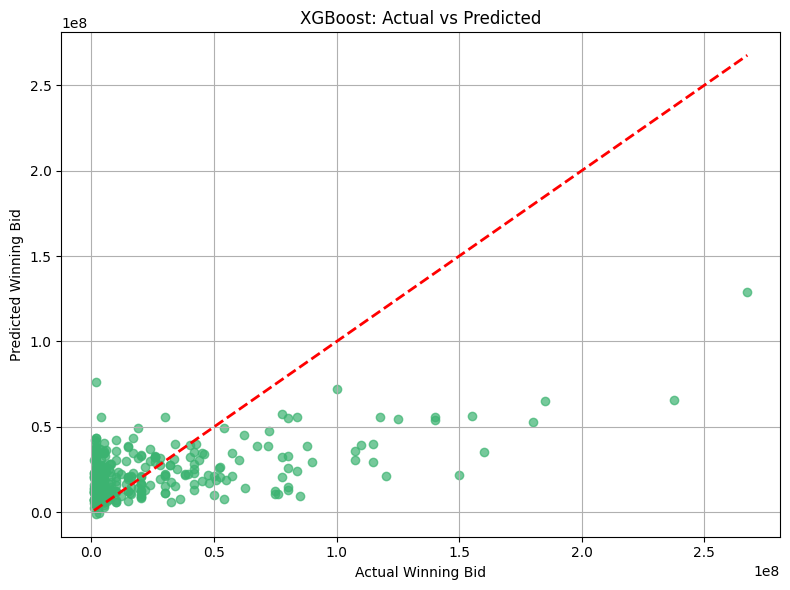

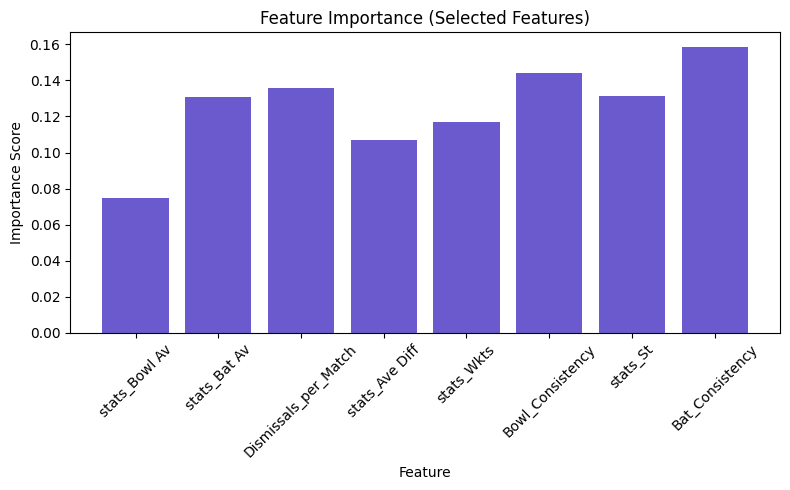

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

xgb = XGBRegressor(random_state=42)
params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(xgb, params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Hyperparameters:", grid.best_params_)

# --- 3. Evaluation ---

y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Optimized R² Score: {r2:.4f}")
print(f"Optimized RMSE: {rmse:.4f}")

# --- 4. Learning Curve ---

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Cross-validation score")
plt.title("Learning Curve - XGBoost")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 5. Actual vs Predicted Plot ---

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Winning Bid")
plt.ylabel("Predicted Winning Bid")
plt.title("XGBoost: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 6. Feature Importance Plot ---

plt.figure(figsize=(8, 5))
plt.bar(important_features, best_model.feature_importances_, color='slateblue')
plt.title("Feature Importance (Selected Features)")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Best Hyperparameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
XGBoost Optimized R² Score: 0.3486
XGBoost Optimized RMSE: 28716535.0148
Best Hyperparameters for KNN: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
KNN Optimized R² Score: 0.3200
KNN Optimized RMSE: 29340806.9358
XGBoost with PCA Optimized R² Score: 0.2613
XGBoost with PCA Optimized RMSE: 30581358.6245
KNN with PCA Optimized R² Score: 0.1294
KNN with PCA Optimized RMSE: 33199939.0603


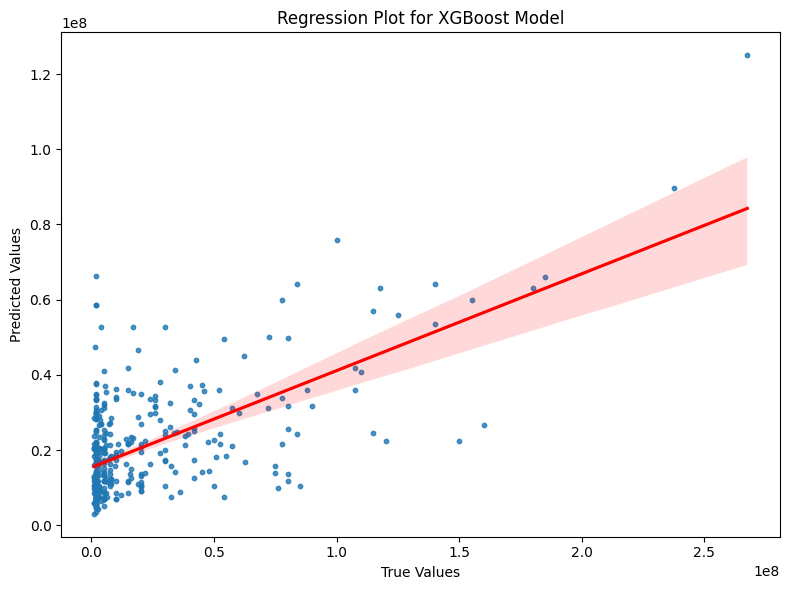

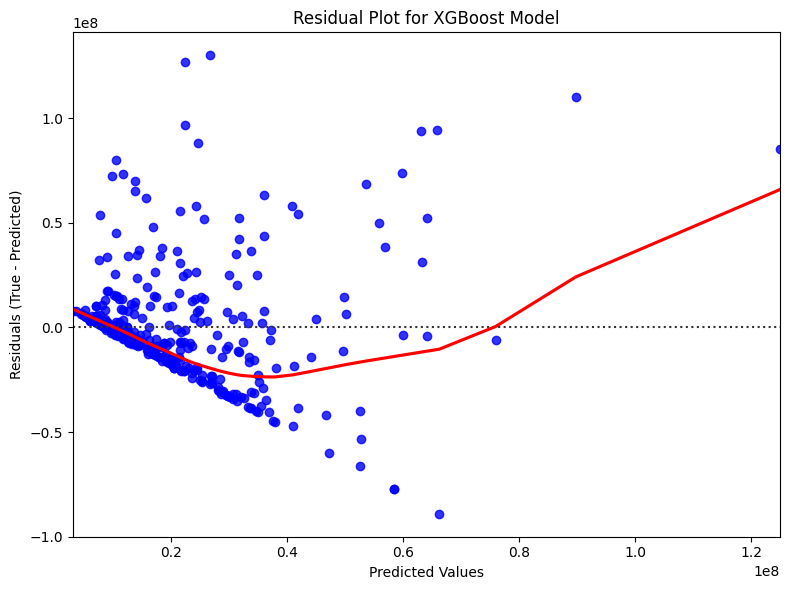

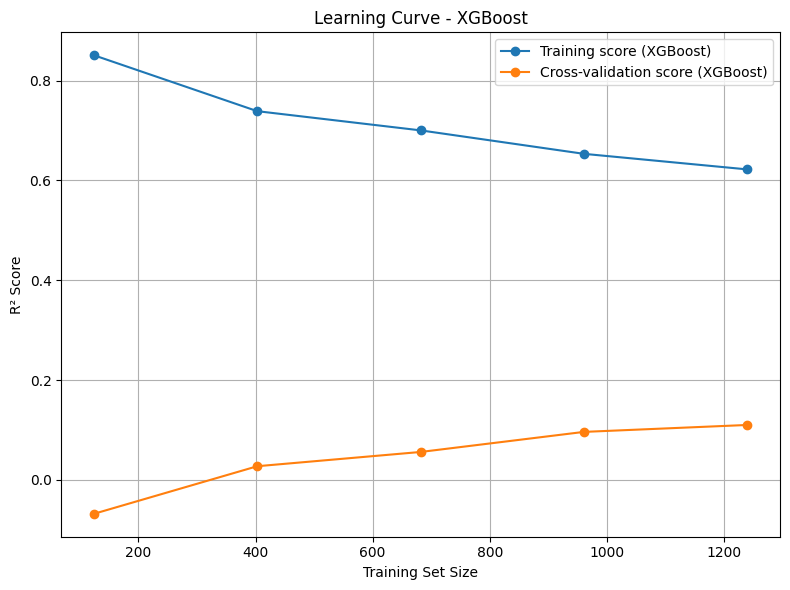

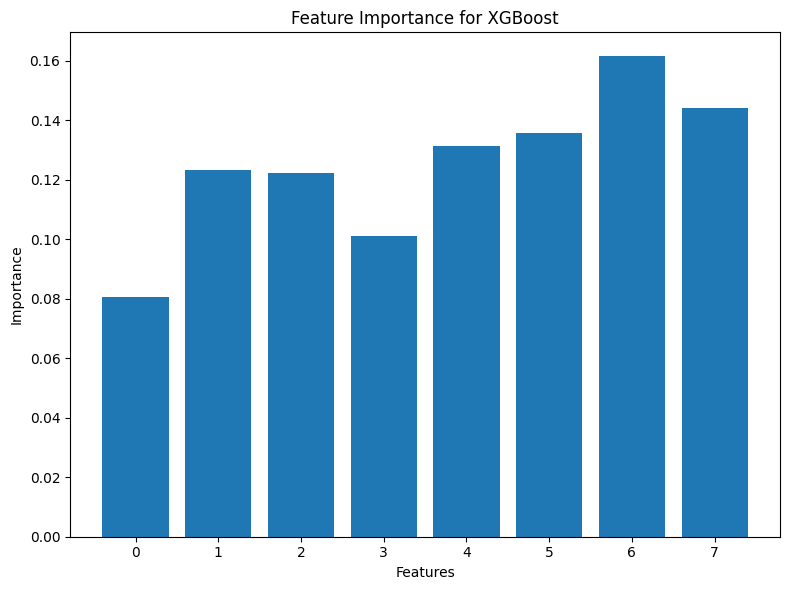

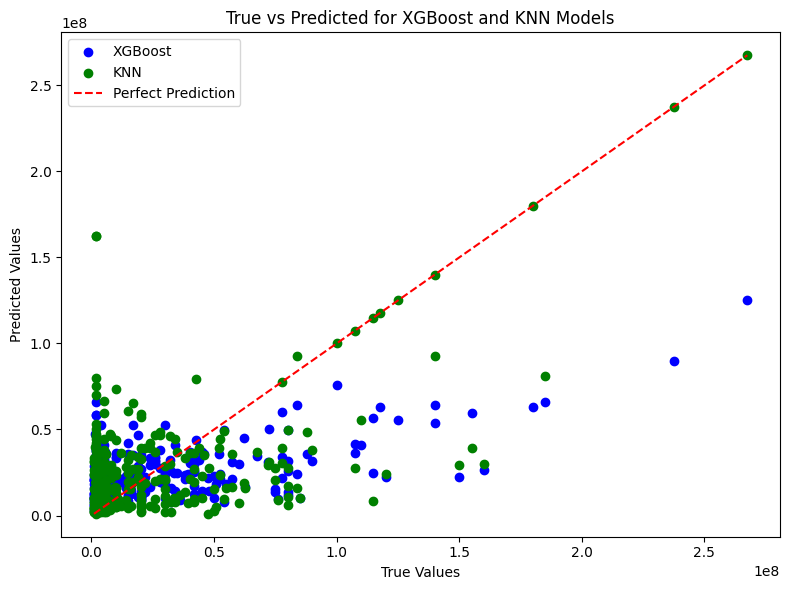

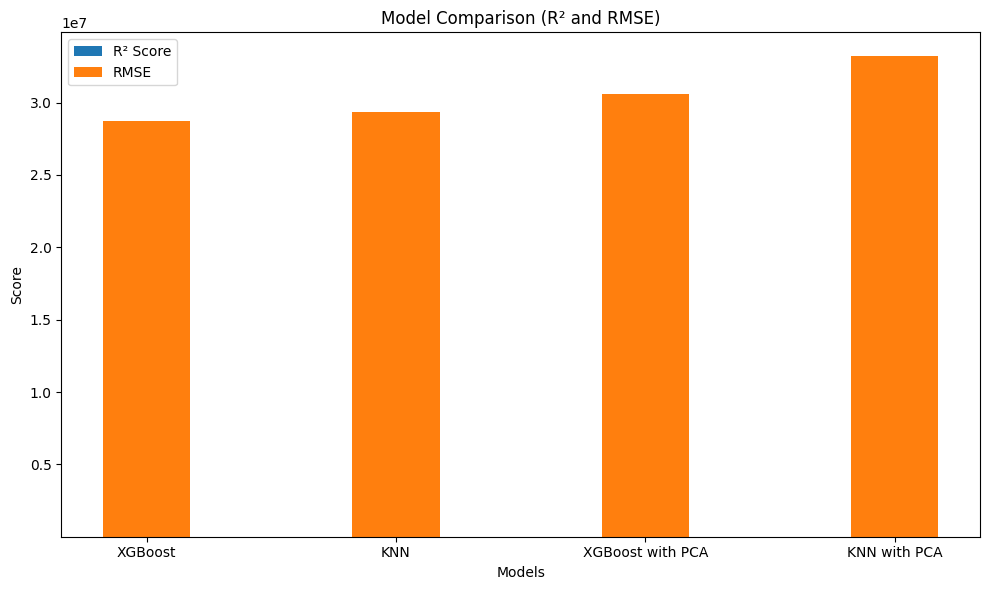


Comparison of Models:
XGBoost R²: 0.3486, RMSE: 28716535.0148
KNN R²: 0.3200, RMSE: 29340806.9358
XGBoost with PCA R²: 0.2613, RMSE: 30581358.6245
KNN with PCA R²: 0.1294, RMSE: 33199939.0603


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load your dataset ---
# Replace this with loading your dataset
# data = pd.read_csv('your_dataset.csv')
# X = data.drop(columns=['target'])
# y = data['target']

# --- Model 1: XGBoost with Hyperparameter Tuning ---
model_xgb = XGBRegressor(random_state=42)

params_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    model_xgb,
    params_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

best_model_xgb = grid_xgb.best_estimator_
print("Best Hyperparameters for XGBoost:", grid_xgb.best_params_)

# Predictions and Evaluation for XGBoost
y_pred_xgb = best_model_xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost Optimized R² Score: {r2_xgb:.4f}")
print(f"XGBoost Optimized RMSE: {rmse_xgb:.4f}")

# --- Model 2: KNN Model ---
model_knn = KNeighborsRegressor()

params_knn = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # p=1 is Manhattan distance, p=2 is Euclidean distance
}

grid_knn = GridSearchCV(
    model_knn,
    params_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

best_model_knn = grid_knn.best_estimator_
print("Best Hyperparameters for KNN:", grid_knn.best_params_)

# Predictions and Evaluation for KNN
y_pred_knn = best_model_knn.predict(X_test)
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print(f"KNN Optimized R² Score: {r2_knn:.4f}")
print(f"KNN Optimized RMSE: {rmse_knn:.4f}")

# --- PCA for Dimensionality Reduction ---
pca = PCA(n_components=5)  # You can adjust n_components based on how many principal components you want to keep
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# --- Model 3: XGBoost with PCA ---
model_xgb_pca = XGBRegressor(random_state=42)
model_xgb_pca.fit(X_train_pca, y_train)

y_pred_xgb_pca = model_xgb_pca.predict(X_test_pca)
r2_xgb_pca = r2_score(y_test, y_pred_xgb_pca)
rmse_xgb_pca = np.sqrt(mean_squared_error(y_test, y_pred_xgb_pca))

print(f"XGBoost with PCA Optimized R² Score: {r2_xgb_pca:.4f}")
print(f"XGBoost with PCA Optimized RMSE: {rmse_xgb_pca:.4f}")

# --- Model 4: KNN with PCA ---
model_knn_pca = KNeighborsRegressor()
model_knn_pca.fit(X_train_pca, y_train)

y_pred_knn_pca = model_knn_pca.predict(X_test_pca)
r2_knn_pca = r2_score(y_test, y_pred_knn_pca)
rmse_knn_pca = np.sqrt(mean_squared_error(y_test, y_pred_knn_pca))

print(f"KNN with PCA Optimized R² Score: {r2_knn_pca:.4f}")
print(f"KNN with PCA Optimized RMSE: {rmse_knn_pca:.4f}")

# --- Visualization 1: Regression Plot (True vs Predicted) ---
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred_xgb, scatter_kws={'s': 10}, line_kws={'color': 'red'})
plt.title('Regression Plot for XGBoost Model')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.tight_layout()
plt.show()

# --- Visualization 2: Residual Plot ---
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred_xgb, y=y_test - y_pred_xgb, lowess=True, color='blue', line_kws={'color': 'red'})
plt.title('Residual Plot for XGBoost Model')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (True - Predicted)')
plt.tight_layout()
plt.show()

# --- Visualization 3: Learning Curve for XGBoost ---
train_sizes, train_scores, test_scores = learning_curve(
    best_model_xgb, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score (XGBoost)")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Cross-validation score (XGBoost)")
plt.title("Learning Curve - XGBoost")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Visualization 4: Feature Importance for XGBoost ---
plt.figure(figsize=(8, 6))
plt.bar(range(len(best_model_xgb.feature_importances_)), best_model_xgb.feature_importances_)
plt.title("Feature Importance for XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# --- Visualization 5: True vs Predicted Plot for Model Comparison ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, color='blue', label='XGBoost')
plt.scatter(y_test, y_pred_knn, color='green', label='KNN')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Perfect Prediction")
plt.title('True vs Predicted for XGBoost and KNN Models')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

# --- Visualization 6: Bar Plot of Model Performance (R² and RMSE) ---
models = ['XGBoost', 'KNN', 'XGBoost with PCA', 'KNN with PCA']
r2_scores = [r2_xgb, r2_knn, r2_xgb_pca, r2_knn_pca]
rmse_scores = [rmse_xgb, rmse_knn, rmse_xgb_pca, rmse_knn_pca]

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
ax.bar(models, r2_scores, width, label='R² Score')
ax.bar(models, rmse_scores, width, bottom=r2_scores, label='RMSE')
ax.set_title("Model Comparison (R² and RMSE)")
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

# --- Model Comparison Summary ---
print("\nComparison of Models:")
print(f"XGBoost R²: {r2_xgb:.4f}, RMSE: {rmse_xgb:.4f}")
print(f"KNN R²: {r2_knn:.4f}, RMSE: {rmse_knn:.4f}")
print(f"XGBoost with PCA R²: {r2_xgb_pca:.4f}, RMSE: {rmse_xgb_pca:.4f}")
print(f"KNN with PCA R²: {r2_knn_pca:.4f}, RMSE: {rmse_knn_pca:.4f}")


In [ ]:
!pip install statsmodels

Best XGBoost Hyperparameters: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': np.float64(0.003593813663804626), 'colsample_bytree': 0.7}

XGBoost Optimized R²: 0.3768
XGBoost Optimized RMSE: 27317910.3755

Stacking Regressor R²: 0.4018
Stacking Regressor RMSE: 26764136.7405


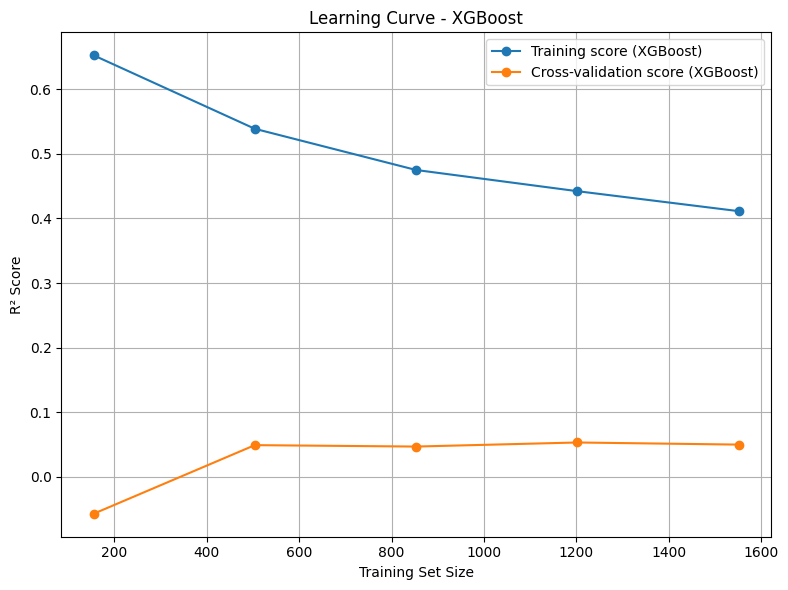

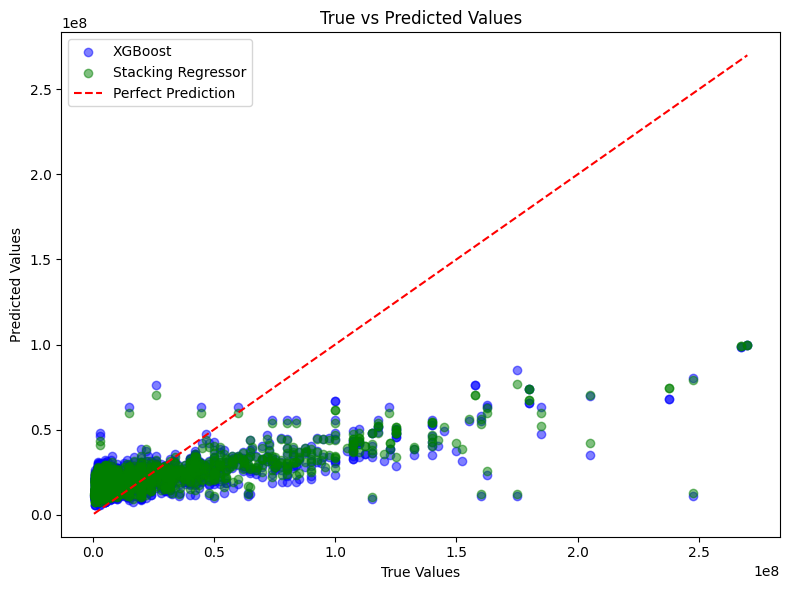


Models successfully saved to 'models' directory:
- scaler.pkl
- best_xgb.pkl
- stacking_model.pkl


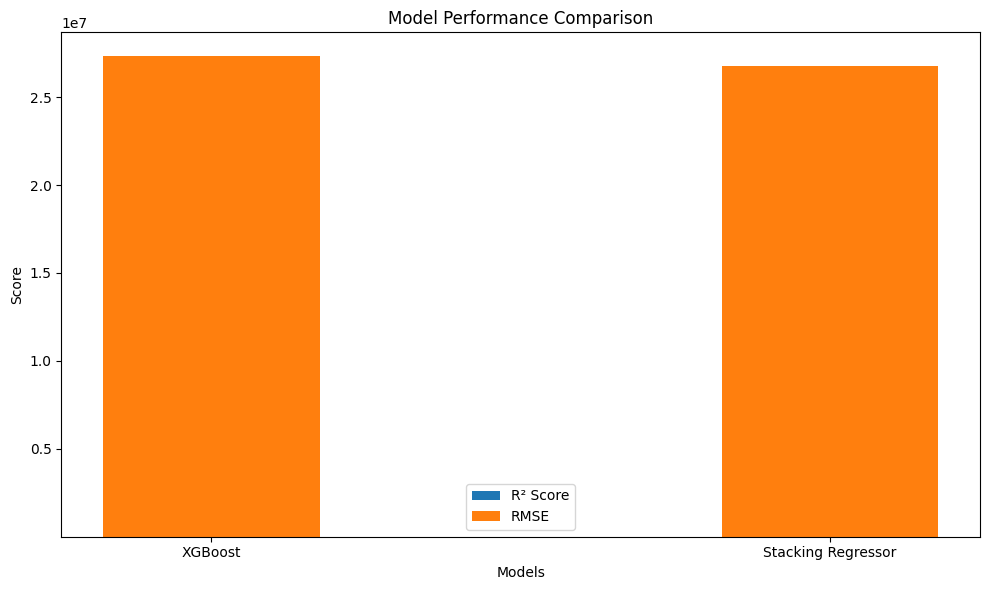

In [ ]:
import numpy as np
import pandas as pd
import pickle
import os
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# --- Feature Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Hyperparameter Tuning for XGBoost ---
xgb_model = XGBRegressor(random_state=42)

xgb_param_dist = {
    'learning_rate': np.logspace(-4, -0.5, 10),
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

random_search_xgb = RandomizedSearchCV(xgb_model, xgb_param_dist, n_iter=50, cv=5,
                                      n_jobs=-1, scoring='r2')
random_search_xgb.fit(X_scaled, y)
print("Best XGBoost Hyperparameters:", random_search_xgb.best_params_)

# --- Build and Evaluate XGBoost Model ---
best_xgb = random_search_xgb.best_estimator_

# Predictions and Evaluation for XGBoost
y_pred_xgb = best_xgb.predict(X_scaled)
r2_xgb = r2_score(y, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y, y_pred_xgb))

print(f"\nXGBoost Optimized R²: {r2_xgb:.4f}")
print(f"XGBoost Optimized RMSE: {rmse_xgb:.4f}")

# --- Ensemble Methods - Stacking Regressor ---
estimators = [
    ('xgb', XGBRegressor(random_state=42, **random_search_xgb.best_params_)),
    ('rf', RandomForestRegressor(random_state=42)),
    ('svr', SVR(kernel='rbf'))
]

stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacking_model.fit(X_scaled, y)

y_pred_stacking = stacking_model.predict(X_scaled)
r2_stacking = r2_score(y, y_pred_stacking)
rmse_stacking = np.sqrt(mean_squared_error(y, y_pred_stacking))

print(f"\nStacking Regressor R²: {r2_stacking:.4f}")
print(f"Stacking Regressor RMSE: {rmse_stacking:.4f}")

# --- Visualization 1: Learning Curve for XGBoost ---
train_sizes, train_scores, test_scores = learning_curve(
    best_xgb, X_scaled, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score (XGBoost)")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Cross-validation score (XGBoost)")
plt.title("Learning Curve - XGBoost")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Visualization 2: True vs Predicted Comparison ---
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_xgb, color='blue', label='XGBoost', alpha=0.5)
plt.scatter(y, y_pred_stacking, color='green', label='Stacking Regressor', alpha=0.5)
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label="Perfect Prediction")
plt.title('True vs Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

# --- Model Persistence ---
# Create models directory
os.makedirs('models', exist_ok=True)

# Save objects
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/best_xgb.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

with open('models/stacking_model.pkl', 'wb') as f:
    pickle.dump(stacking_model, f)

print("\nModels successfully saved to 'models' directory:")
print("- scaler.pkl")
print("- best_xgb.pkl")
print("- stacking_model.pkl")

# --- Optional: Performance Comparison Plot ---
models = ['XGBoost', 'Stacking Regressor']
r2_scores = [r2_xgb, r2_stacking]
rmse_scores = [rmse_xgb, rmse_stacking]

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
ax.bar(models, r2_scores, width, label='R² Score')
ax.bar(models, rmse_scores, width, bottom=r2_scores, label='RMSE')
ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

Best XGBoost Hyperparameters: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 400, 'subsample': 0.7}
XGBoost Optimized R²: 0.4069
XGBoost Optimized RMSE: 1.0777
Stacking Regressor R²: 0.3794
Stacking Regressor RMSE: 1.1025


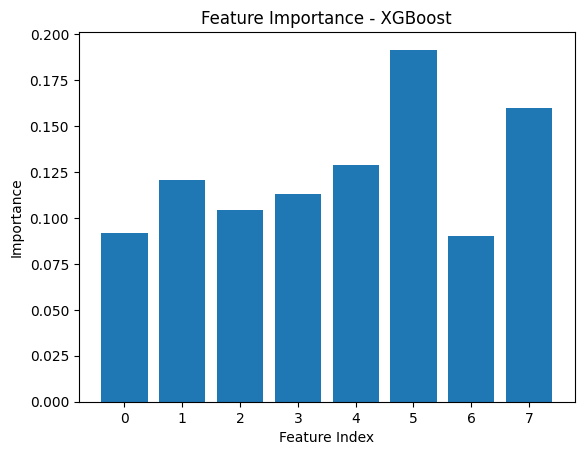

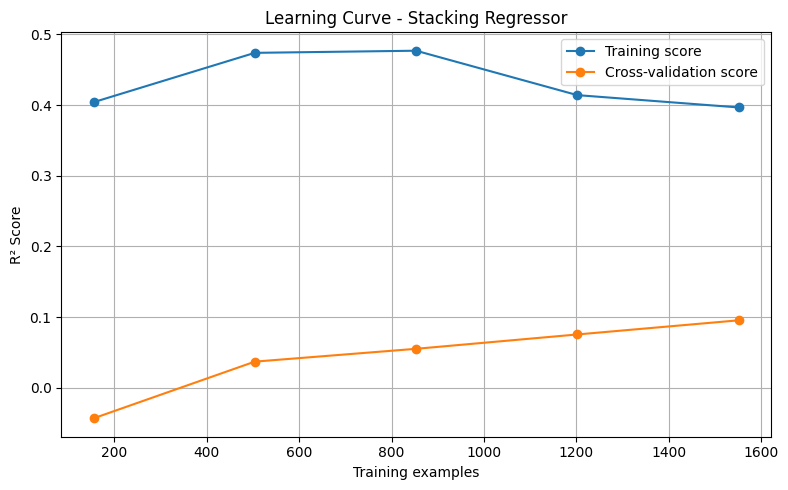

All models and scalers have been saved to the 'best' folder.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt

# Step 1: Select Important Features


# Filter the dataset to keep only the important features
df_selected = ipl_data[important_features + ['WinningBid']]  # Including the target variable 'WinningBid'

# Step 2: Feature Engineering (Log Transform for Target Variable if skewed)
df_selected['log_WinningBid'] = np.log(df_selected['WinningBid'] + 1)  # Log Transformation of target variable

# Re-prepare features and target
X = df_selected.drop(columns=['WinningBid', 'log_WinningBid'])  # Keep numeric features
y = df_selected['log_WinningBid']  # Use transformed target

# Step 3: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Feature Selection using Recursive Feature Elimination (RFE)
selector = RFECV(XGBRegressor(random_state=42), step=1, cv=5)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.support_]

# Step 5: Hyperparameter Tuning using GridSearchCV for XGBoost
xgb_model = XGBRegressor(random_state=42)

xgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

grid_search_xgb = GridSearchCV(xgb_model, xgb_param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_xgb.fit(X_selected, y)

# Get best model and hyperparameters
best_xgb = grid_search_xgb.best_estimator_
print("Best XGBoost Hyperparameters:", grid_search_xgb.best_params_)

# Step 6: Build and Evaluate XGBoost Model
y_pred_xgb = best_xgb.predict(X_selected)
r2_xgb = r2_score(y, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y, y_pred_xgb))

print(f"XGBoost Optimized R²: {r2_xgb:.4f}")
print(f"XGBoost Optimized RMSE: {rmse_xgb:.4f}")

# Step 7: Ensemble Methods - Stacking Regressor
estimators = [
    ('xgb', best_xgb),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42)),
    ('svr', SVR(kernel='rbf', C=10, epsilon=0.1))
]

stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacking_model.fit(X_selected, y)

y_pred_stacking = stacking_model.predict(X_selected)
r2_stacking = r2_score(y, y_pred_stacking)
rmse_stacking = np.sqrt(mean_squared_error(y, y_pred_stacking))

print(f"Stacking Regressor R²: {r2_stacking:.4f}")
print(f"Stacking Regressor RMSE: {rmse_stacking:.4f}")

# Step 8: Plotting Feature Importances (for XGBoost)
import matplotlib.pyplot as plt
plt.bar(range(len(best_xgb.feature_importances_)), best_xgb.feature_importances_)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# Optionally: Learning Curve for Stacking Regressor
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(stacking_model, X_selected, y, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Cross-validation score")
plt.title("Learning Curve - Stacking Regressor")
plt.xlabel("Training examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


import joblib
import os

# Create the 'best' folder if it doesn't exist
os.makedirs('best', exist_ok=True)

# Dump models and other useful objects
joblib.dump(best_xgb, 'best/best_xgb.pkl')
joblib.dump(stacking_model, 'best/stacking_model.pkl')
joblib.dump(scaler, 'best/scaler.pkl')
joblib.dump(selector, 'best/feature_selector.pkl')

print("All models and scalers have been saved to the 'best' folder.")



Best test size ratio: 0.10 with R²: 0.2208
Selected features: ['Dismissals_per_Match', 'stats_Ave Diff', 'stats_Runs', 'stats_Wkts', 'Bowl_Consistency', 'Bat_Consistency']
Fitting 5 folds for each of 46656 candidates, totalling 233280 fits
Best XGBoost Hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.3, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 1.0}
XGBoost Train R²: 0.7878
XGBoost Test R²: 0.3136

Stacking Regressor Train R²: 0.7396
Stacking Regressor Test R²: 0.3274


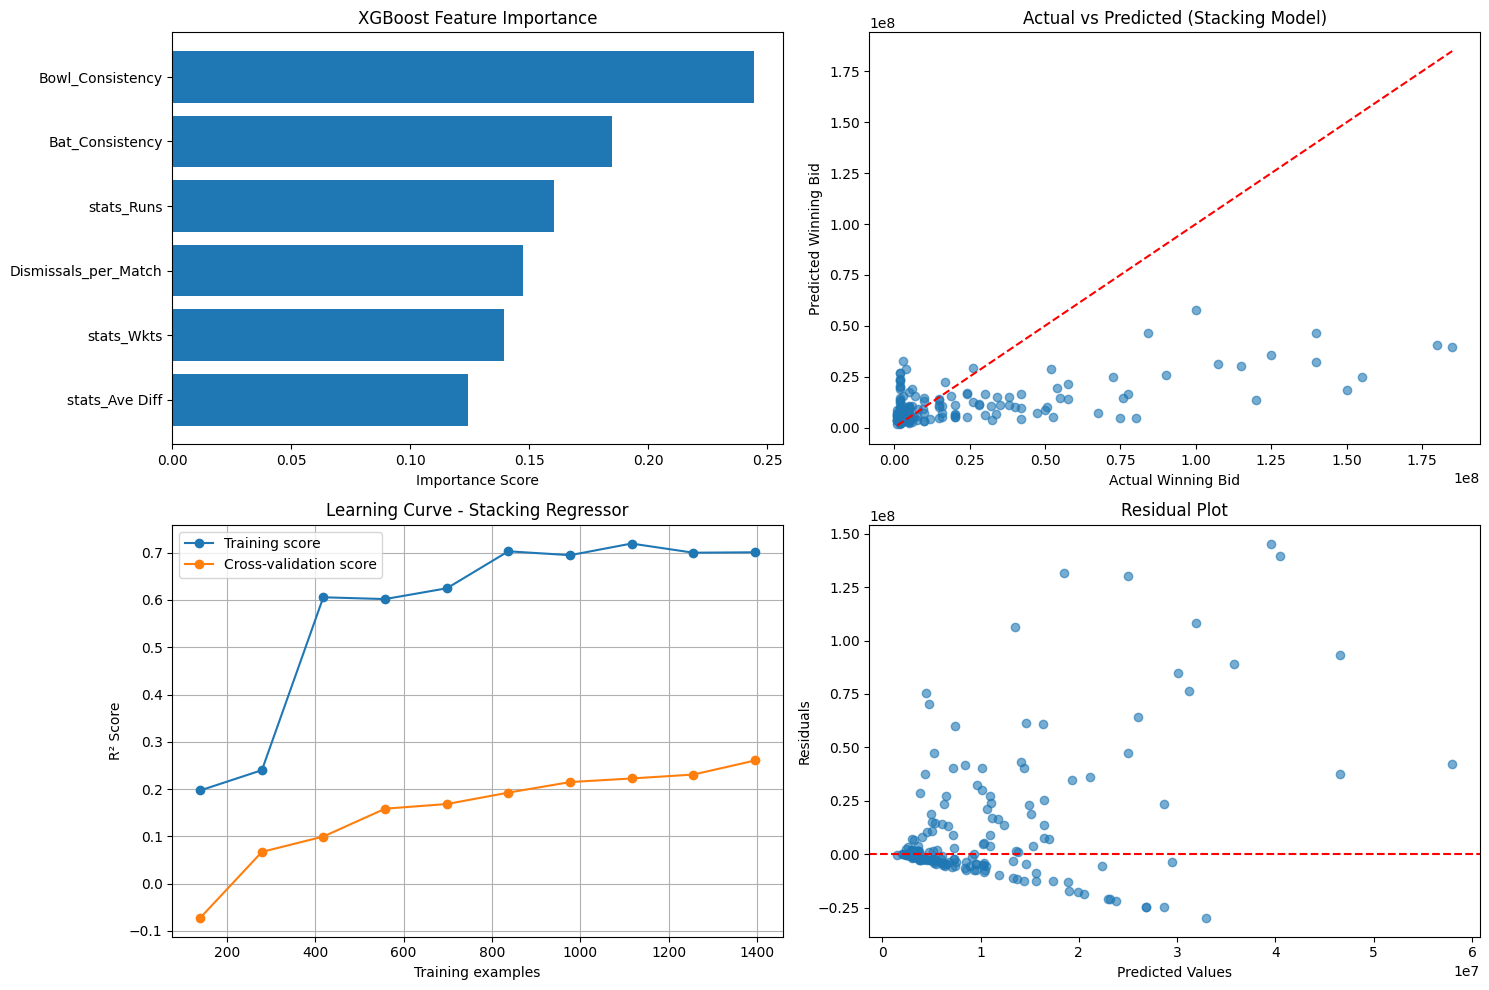

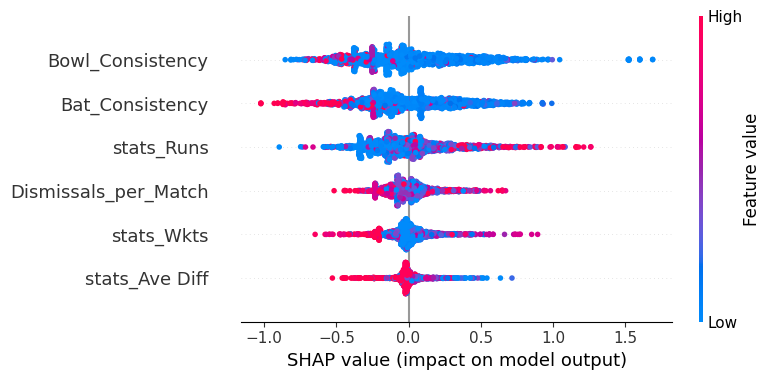

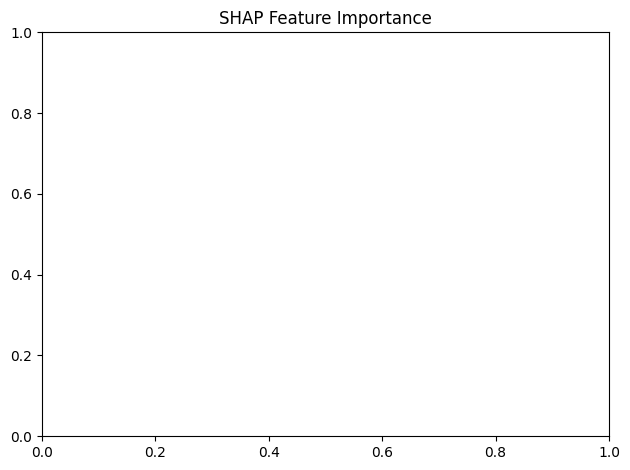

Model saved as 'ipl_auction_model.pkl'


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import shap

# Set random seed for reproducibility
np.random.seed(42)

# Step 1: Select Important Features
important_features = [
    'stats_Bowl Av', 'Dismissals_per_Match', 'stats_Ave Diff',
    'stats_Runs', 'stats_Wkts', 'Bowl_Consistency',
    'stats_St', 'Bat_Consistency'
]

# Filter the dataset to keep only the important features
df_selected = ipl_data[important_features + ['WinningBid']]  # Including the target variable 'WinningBid'


# Feature Engineering
df_selected['log_WinningBid'] = np.log1p(df_selected['WinningBid'])  # Better than log(x+1)
X = df_selected.drop(columns=['WinningBid', 'log_WinningBid'])
y = df_selected['log_WinningBid']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optimized Train-Test Split
# We'll find the best split ratio by evaluating validation error
split_ratios = np.linspace(0.1, 0.4, 10)  # Testing from 10-40% test size
best_ratio = 0.2
best_score = -np.inf

for ratio in split_ratios:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=ratio, random_state=42)

    # Use XGBoost as base model to evaluate split
    model = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.9,
        random_state=42
    )

    # Cross-validation score
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    mean_score = np.mean(scores)

    if mean_score > best_score:
        best_score = mean_score
        best_ratio = ratio

print(f"Best test size ratio: {best_ratio:.2f} with R²: {best_score:.4f}")

# Final train-test split with best ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=best_ratio,
    random_state=42
)

# Feature Selection with RFECV on training data only
selector = RFECV(
    estimator=XGBRegressor(random_state=42),
    step=1,
    cv=5,
    scoring='r2',
    min_features_to_select=4
)
selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)
selected_features = X.columns[selector.support_]

print(f"Selected features: {list(selected_features)}")

# Enhanced XGBoost Model with more thorough hyperparameter tuning
xgb_model = XGBRegressor(random_state=42)

xgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1],
    'min_child_weight': [1, 3, 5]
}

grid_search_xgb = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_xgb.fit(X_train_selected, y_train)

best_xgb = grid_search_xgb.best_estimator_
print("Best XGBoost Hyperparameters:", grid_search_xgb.best_params_)

# Evaluate XGBoost
y_pred_xgb_train = best_xgb.predict(X_train_selected)
y_pred_xgb_test = best_xgb.predict(X_test_selected)

r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print(f"XGBoost Train R²: {r2_xgb_train:.4f}")
print(f"XGBoost Test R²: {r2_xgb_test:.4f}")

# Enhanced Stacking Regressor
estimators = [
    ('xgb', best_xgb),
    ('rf', RandomForestRegressor(
        n_estimators=300,
        max_depth=9,
        min_samples_split=5,
        random_state=42
    )),
    ('svr', SVR(
        kernel='rbf',
        C=10,
        epsilon=0.1,
        gamma='scale'
    ))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    passthrough=True,
    cv=5
)

stacking_model.fit(X_train_selected, y_train)

y_pred_stack_train = stacking_model.predict(X_train_selected)
y_pred_stack_test = stacking_model.predict(X_test_selected)

r2_stack_train = r2_score(y_train, y_pred_stack_train)
r2_stack_test = r2_score(y_test, y_pred_stack_test)

print(f"\nStacking Regressor Train R²: {r2_stack_train:.4f}")
print(f"Stacking Regressor Test R²: {r2_stack_test:.4f}")

# Model Visualization
plt.figure(figsize=(15, 10))

# 1. Feature Importance
plt.subplot(2, 2, 1)
sorted_idx = best_xgb.feature_importances_.argsort()
plt.barh(range(len(sorted_idx)), best_xgb.feature_importances_[sorted_idx])
plt.yticks(range(len(sorted_idx)), selected_features[sorted_idx])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")

# 2. Actual vs Predicted Plot
plt.subplot(2, 2, 2)
plt.scatter(np.expm1(y_test), np.expm1(y_pred_stack_test), alpha=0.6)
plt.plot([min(np.expm1(y_test)), max(np.expm1(y_test))],
         [min(np.expm1(y_test)), max(np.expm1(y_test))], 'r--')
plt.title("Actual vs Predicted (Stacking Model)")
plt.xlabel("Actual Winning Bid")
plt.ylabel("Predicted Winning Bid")

# 3. Learning Curve
plt.subplot(2, 2, 3)
train_sizes, train_scores, test_scores = learning_curve(
    stacking_model, X_train_selected, y_train, cv=5,
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation score")
plt.title("Learning Curve - Stacking Regressor")
plt.xlabel("Training examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)

# 4. Residual Plot
plt.subplot(2, 2, 4)
residuals = np.expm1(y_test) - np.expm1(y_pred_stack_test)
plt.scatter(np.expm1(y_pred_stack_test), residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

# SHAP Values for model interpretation
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_train_selected)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_selected, feature_names=selected_features)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

# Save the best model and preprocessing objects
model_pipeline = Pipeline([
    ('scaler', scaler),
    ('selector', selector),
    ('model', stacking_model)
])
joblib.dump(model_pipeline, 'ipl_auction_model.pkl')
print("Model saved as 'ipl_auction_model.pkl'")

In [ ]:
pip install gradio numpy pandas scikit-learn

  Using cached gradio-5.29.0-py3-none-any.whl.metadata (16 kB)
  Using cached aiofiles-24.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached fastapi-0.115.12-py3-none-any.whl.metadata (27 kB)
  Using cached ffmpy-0.5.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached gradio_client-1.10.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached huggingface_hub-0.31.1-py3-none-any.whl.metadata (13 kB)
  Using cached orjson-3.10.18-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (41 kB)
  Using cached pydantic-2.11.4-py3-none-any.whl.metadata (66 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached python_multipart-0.0.20-py3-none-any.whl.metadata (1.8 kB)
  Using cached ruff-0.11.9-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (25 kB)
  Using cached safehttpx-0.1.6-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.

Selected features: Dismissals_per_Match, stats_Bowl Av, stats_Ave Diff, stats_St, stats_Wkts, stats_Bat Av, Bowl_Consistency, Bat_Consistency
GPU acceleration not available, using CPU mode for XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Hyperparameters: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
XGBoost Training R²: 0.7856
XGBoost Test R²: 0.2372
XGBoost Test RMSE: 1.2409
Weighted Ensemble Test R²: 0.2391
Weighted Ensemble Test RMSE: 1.2393
Feature importance chart saved as 'feature_importance.png'

Total execution time: 11.34 seconds
Model saved as 'best_xgb_model.pkl'
Selected features saved as 'selected_features.txt'
Scaler saved as 'scaler.pkl'

Model artifacts saved in 'model_artifacts' directory:
['model_metadata.json', 'best_xgb_model.pkl', 'feature_metadata.csv', 'scaler.pkl']


{'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...),
 'ensemble_r2': 0.2390720341821252,
 'ensemble_rmse': np.float64(1.2393154409231228),
 'xgb_test_r2': 0.23717146668211564,
 'selected_features': Index(['Dismissals_per_Match', 'stats_Bowl Av', 'stats_Ave Diff', 'stats_St',
        'stats_Wkts

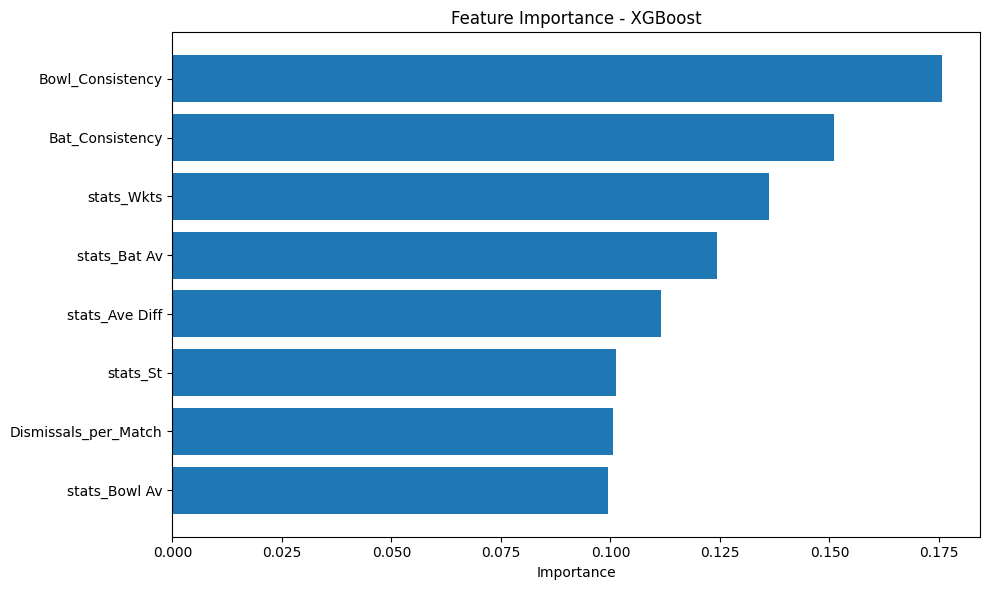

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from joblib import parallel_backend, Parallel, delayed

# Start timing
start_time = time.time()

# Step 1: Select Important Features (assuming important_features is already defined)
df_selected = ipl_data[important_features + ['WinningBid']]

# Step 2: Feature Engineering - Log Transform for Target Variable
df_selected['log_WinningBid'] = np.log(df_selected['WinningBid'] + 1)

# Prepare features and target
X = df_selected.drop(columns=['WinningBid', 'log_WinningBid'])
y = df_selected['log_WinningBid']

# Split the data - add train/test split to avoid overfitting and get realistic performance metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Feature Scaling - apply to training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Fast Feature Selection using correlation for pre-filtering
# This is much faster than RFECV while still effective
corr_with_target = np.abs(np.corrcoef(np.concatenate([X_train_scaled, y_train.values.reshape(-1, 1)], axis=1).T)[-1, :-1])
top_feature_indices = np.argsort(corr_with_target)[-min(15, len(corr_with_target)):]  # Take top 15 or less
X_train_selected = X_train_scaled[:, top_feature_indices]
X_test_selected = X_test_scaled[:, top_feature_indices]
selected_features = X.columns[top_feature_indices]

print(f"Selected features: {', '.join(selected_features)}")

# Step 5: Optimized Hyperparameter Tuning using RandomizedSearchCV (faster than GridSearchCV)
# Configure XGBoost for GPU acceleration if available
# Check for GPU availability using a safer method
try:
    # Try to create a small XGBoost model with GPU configuration
    test_gpu = xgb.XGBRegressor(tree_method='gpu_hist', device = 'CUDA')
    test_gpu.fit(np.random.randn(10, 5), np.random.randn(10))
    gpu_params = {'tree_method': 'gpu_hist', 'predictor': 'gpu_predictor'}
    print("GPU acceleration enabled for XGBoost")
except Exception:
    # Fall back to CPU if GPU initialization fails
    gpu_params = {}
    print("GPU acceleration not available, using CPU mode for XGBoost")

xgb_model = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,  # Use all cores
    **gpu_params
)

# Focused parameter grid with fewer combinations but maintaining good coverage
xgb_param_dist = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300],
    'max_depth': [5, 7],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'gamma': [0, 0.1],
    'min_child_weight': [1, 3]
}

# Use RandomizedSearchCV instead of GridSearchCV for speed
with parallel_backend('threading', n_jobs=-1):
    search_xgb = RandomizedSearchCV(
        xgb_model,
        param_distributions=xgb_param_dist,
        n_iter=10,  # Try 10 combinations instead of all combinations
        cv=3,       # Reduced from 5 to 3 folds for speed
        scoring='r2',
        verbose=1
    )
    search_xgb.fit(X_train_selected, y_train)

# Get best model
best_xgb = search_xgb.best_estimator_
print("Best XGBoost Hyperparameters:", search_xgb.best_params_)

# Step 6: Optimized XGBoost Model Evaluation
y_pred_xgb_train = best_xgb.predict(X_train_selected)
y_pred_xgb_test = best_xgb.predict(X_test_selected)

r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))

print(f"XGBoost Training R²: {r2_xgb_train:.4f}")
print(f"XGBoost Test R²: {r2_xgb_test:.4f}")
print(f"XGBoost Test RMSE: {rmse_xgb_test:.4f}")

# Step 7: Lightweight Ensemble - Using only the best model types for speed
# Train RandomForest with reduced complexity
with parallel_backend('threading', n_jobs=-1):
    rf_model = RandomForestRegressor(
        n_estimators=100,  # Reduced from 200
        max_depth=7,
        random_state=42,
        n_jobs=-1          # Use all CPU cores
    )
    rf_model.fit(X_train_selected, y_train)

# Ensemble prediction using weighted average (faster than StackingRegressor)
rf_weight = 0.3
xgb_weight = 0.7  # Give more weight to XGBoost if it's performing better

y_pred_rf_test = rf_model.predict(X_test_selected)
y_pred_ensemble_test = (xgb_weight * y_pred_xgb_test) + (rf_weight * y_pred_rf_test)

r2_ensemble_test = r2_score(y_test, y_pred_ensemble_test)
rmse_ensemble_test = np.sqrt(mean_squared_error(y_test, y_pred_ensemble_test))

print(f"Weighted Ensemble Test R²: {r2_ensemble_test:.4f}")
print(f"Weighted Ensemble Test RMSE: {rmse_ensemble_test:.4f}")

# Step 8: Quick Feature Importance Visualization
import matplotlib.pyplot as plt

# Get feature importances
feature_importance = best_xgb.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), [selected_features[i] for i in sorted_idx])
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)  # Save instead of displaying to avoid blocking
print("Feature importance chart saved as 'feature_importance.png'")

# Calculate and print execution time
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

# Optional: Save the best model for future quick inference
import joblib
joblib.dump(best_xgb, 'best_xgb_model.pkl')
print("Model saved as 'best_xgb_model.pkl'")
# Dump selected features to a text file
with open('selected_features.txt', 'w') as f:
    for feature in selected_features:
        f.write(f"{feature}\n")
print("Selected features saved as 'selected_features.txt'")

# Save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")


# Return the final model and metrics
results = {
    'model': best_xgb,
    'ensemble_r2': r2_ensemble_test,
    'ensemble_rmse': rmse_ensemble_test,
    'xgb_test_r2': r2_xgb_test,  # Add this line
    'selected_features': selected_features,
    'last_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')
}


# ... [Keep all previous code until the end] ...

# Modified saving section to ensure proper feature handling
# Save model components in a dedicated directory
import os
os.makedirs('model_artifacts', exist_ok=True)

# Save model with feature names
best_xgb.get_booster().feature_names = selected_features.tolist()  # Explicitly set feature names
joblib.dump(best_xgb, 'model_artifacts/best_xgb_model.pkl')
import json
with open('model_artifacts/model_metadata.json', 'w') as f:
    json.dump({
        'test_r2': r2_xgb_test,
        'last_trained': results['last_trained'],
        'num_features': len(selected_features)
    }, f)
# Save scaler with feature names
scaler.feature_names_in_ = selected_features.tolist()
joblib.dump(scaler, 'model_artifacts/scaler.pkl')

# Save feature metadata
pd.DataFrame({
    'feature_names': selected_features,
    'importance': best_xgb.feature_importances_
}).to_csv('model_artifacts/feature_metadata.csv', index=False)

print("\nModel artifacts saved in 'model_artifacts' directory:")
print(os.listdir('model_artifacts'))

results

In [ ]:
import gradio as gr
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load model components
model = joblib.load('model_artifacts/best_xgb_model.pkl')
scaler = joblib.load('model_artifacts/scaler.pkl')
feature_metadata = pd.read_csv('model_artifacts/feature_metadata.csv')
selected_features = feature_metadata['feature_names'].tolist()

# Create feature descriptions with validation
feature_ranges = {
    'stats_Bowl Av': (15, 40),
    'stats_Bat Av': (10, 60),
    'Dismissals_per_Match': (0, 2.5),
    'stats_Ave Diff': (-30, 30),
    'stats_Wkts': (0, 300),
    'Bowl_Consistency': (0, 10),
    'stats_St': (0, 100),
    'Bat_Consistency': (0, 10)
}

def create_feature_input(feature):
    """Dynamically create input components with validation"""
    if feature in feature_ranges:
        min_val, max_val = feature_ranges[feature]
        return gr.Slider(
            label=feature.replace('_', ' ').title(),
            minimum=min_val,
            maximum=max_val,
            value=(min_val + max_val)/2,
            step=0.1 if 'Av' in feature else 1
        )
    return gr.Number(label=feature.replace('_', ' ').title())

def predict_bid(**inputs):
    """Make prediction with feature order validation"""
    # Create DataFrame with EXACT feature order
    input_df = pd.DataFrame(columns=selected_features)
    for feature in selected_features:
        input_df[feature] = [inputs.get(feature, 0)]

    # Validate feature order
    if list(input_df.columns) != selected_features:
        raise ValueError(f"Feature order mismatch! Expected: {selected_features}")

    # Scale and predict
    scaled_data = scaler.transform(input_df)
    log_pred = model.predict(scaled_data)[0]
    prediction = np.exp(log_pred) - 1  # Convert from log scale

    # Create visualization
    plt.figure(figsize=(10, 6))
    plt.barh(selected_features, model.feature_importances_)
    plt.title("Feature Importance")
    plt.xlabel("Importance Score")
    plt.tight_layout()

    return f"₹{prediction:,.2f} Lakhs", plt

# Create interface
with gr.Blocks(title="IPL Bid Predictor") as app:
    gr.Markdown("# IPL Player Bid Prediction Engine")

    # Dynamic input creation
    with gr.Row():
        with gr.Column():
            inputs = [create_feature_input(feat) for feat in selected_features]
            predict_btn = gr.Button("Predict Bid Value", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(label="Predicted Bid Value")
            output_plot = gr.Plot(label="Feature Importance Analysis")

   # Load metadata
        with open('model_artifacts/model_metadata.json') as f:
            model_meta = json.load(f)

# Update the Markdown section
            gr.Markdown(f"""
            - **Model Type**: XGBoost Regressor
            - **Features Used**: {model_meta['num_features']} most impactful parameters
            - **Validation R² Score**: {model_meta['test_r2']:.2f}
            - **Last Trained**: {model_meta['last_trained']}
            """)

    predict_btn.click(
        fn=predict_bid,
        inputs=inputs,
        outputs=[output_text, output_plot]
    )

# Launch the app
if __name__ == "__main__":
    app.launch(
        server_name="0.0.0.0",
        server_port=7866,
        share=False,
        favicon_path="https://www.iplt20.com/assets/images/favicon.ico"
    )

* Running on local URL:  http://0.0.0.0:7866
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/gaurav/myenv/lib/python3.12/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gaurav/myenv/lib/python3.12/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gaurav/myenv/lib/python3.12/site-packages/gradio/blocks.py", line 2146, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gaurav/myenv/lib/python3.12/site-packages/gradio/blocks.py", line 1664, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gaurav/myenv/lib/python3.12/site-packages/anyio/to_thread.py", line 56, in run_sync
    return await get_async_backend().run